In [84]:
!pip install squarify

In [85]:
#Data Handling
import pandas as pd 
import numpy as np
import squarify

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

obesity = pd.read_csv(r"ObesityDataSet_raw_and_data_sinthetic.csv")

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

obesity

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,44.071535


1. Dataset Overview

In [86]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [87]:
obesity.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III,44.071535
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III,44.144338


In [88]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [89]:
print("Rows:", obesity.shape[0])
print("Columns:", obesity.shape[1])
print()
print("Memory Usage:")
print(obesity.memory_usage(deep=True))

Rows: 2111
Columns: 18

Memory Usage:
Index                                132
Gender                            113969
Age                                16888
Height                             16888
Weight                             16888
family_history_with_overweight    109387
FAVC                              109527
FCVC                               16888
NCP                                16888
CAEC                              122164
SMOKE                             107705
CH2O                               16888
SCC                               107757
FAF                                16888
TUE                                16888
CALC                              118032
MTRANS                            141708
NObeyesdad                        137621
BMI                                16888
dtype: int64


Exp : Dataset contains 2111 observations and 17 attributes. Each row represents an individual's demographic characteristics, lifestyle habits, and obesity classification.

2. Data Type Analysis (不要只是看dtype)

In [90]:
numeric = obesity.select_dtypes(include=np.number)

categorical = obesity.select_dtypes(exclude=np.number)

print("Numerical Features")
print(numeric.columns)

print()

print("Categorical Features")
print(categorical.columns)
print()
print("Number of Numerical Features:", len(numeric.columns))
print("Number of Categorical Features:", len(categorical.columns))

Numerical Features
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')

Categorical Features
Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

Number of Numerical Features: 9
Number of Categorical Features: 9


Exp: 
The dataset consists of 9 numerical features and 9 categorical features. Numerical variables will be used for statistical analysis, while categorical variables will require encoding before model training.

| Type        | Number |
| ----------- | ------ |
| Numerical   | 9      |
| Categorical | 9      |


3. Summary Statistics

In [91]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866,29.700159
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927,8.011337
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.998685
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000,24.325802
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350,28.719089
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000,36.016501
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.811753


Exp:  
请回答：

平均年龄是多少？
最大体重是多少？
身高范围是多少？

例如：
Participants' ages range from 14 to 61 years, with an average age of approximately 24 years.

4. Unique Value Analysis(统计每个栏位有几个不同值）
   Purpose: 1.哪一个适合encoding
            2.哪一个适合one-hot encoding
            3.哪一个适合continuous data

In [92]:
for col in obesity.columns:
    print(col, ":", obesity[col].nunique())

Gender : 2
Age : 1402
Height : 1574
Weight : 1525
family_history_with_overweight : 2
FAVC : 2
FCVC : 810
NCP : 635
CAEC : 4
SMOKE : 2
CH2O : 1268
SCC : 2
FAF : 1190
TUE : 1129
CALC : 4
MTRANS : 5
NObeyesdad : 7
BMI : 1968


5. Target Variable Analysis **Very Important

In [93]:
obesity['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

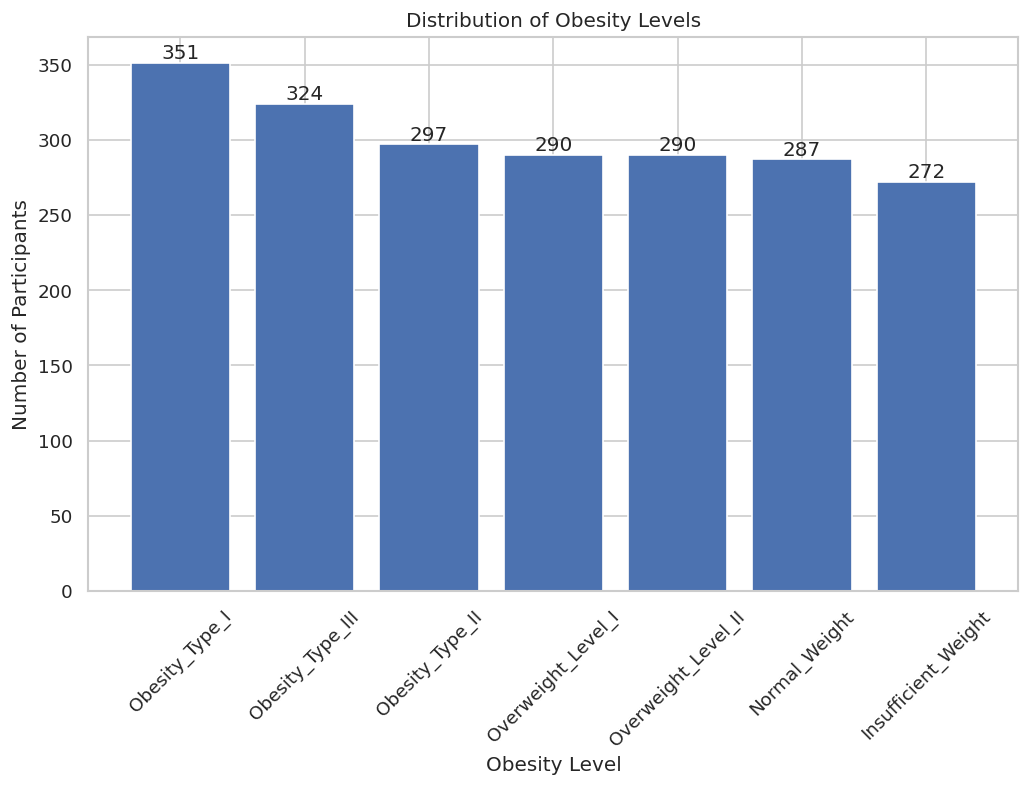

In [94]:
counts = obesity['NObeyesdad'].value_counts()

plt.figure(figsize=(10,6))
bars = plt.bar(counts.index, counts.values)

plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Participants")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

Report : 
Before building the classification models, the target variable (NObeyesdad) was analysed. The class distribution showed that all obesity categories contain a relatively similar number of observations. Therefore, the dataset is considered reasonably balanced, reducing the risk of model bias toward a dominant class.

6. Distribution Analysis

Purpose: The purpose of this section is to examine the distribution of numerical variables in the dataset. Understanding the distribution helps identify data characteristics such as central tendency, spread, skewness, kurtosis, and potential outliers before building machine learning models.

6.1. Age Distribution

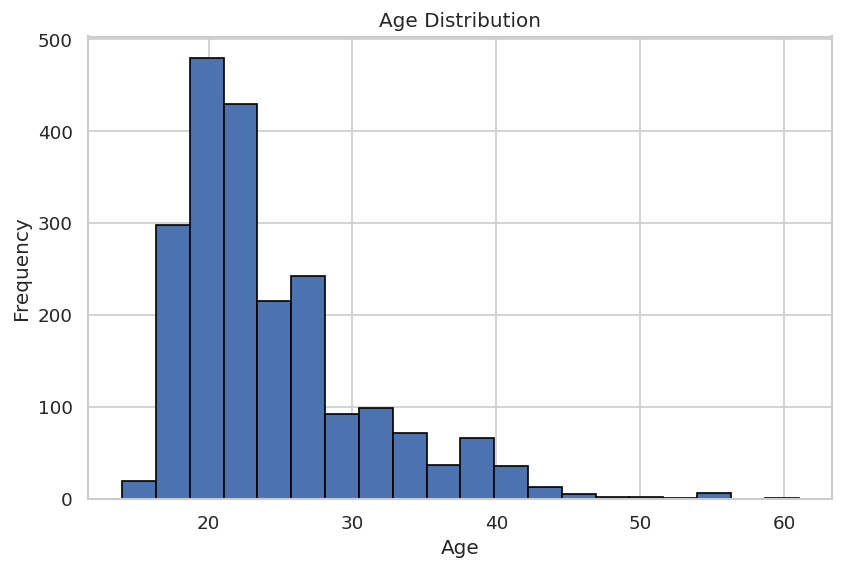

In [95]:
plt.figure(figsize=(8,5))

plt.hist(obesity['Age'], bins=20, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [96]:
print(obesity["Age"].describe())
print()
print("Skewness :", round(obesity["Age"].skew(),2))
print()
print("Kurtosis :", round(obesity["Age"].kurt(),2))


count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64

Skewness : 1.53

Kurtosis : 2.83


Report:
The Age variable is positively skewed, indicating that most participants are relatively young while only a small number of participants are older.

Report:
The Age distribution is positively skewed (Skewness = 1.53), indicating that most participants are concentrated in the younger age groups. The kurtosis value of 2.83 suggests a relatively peaked distribution with several extreme observations.

Conclude:

Age

The Age variable is positively skewed, indicating that most participants are relatively young. The kurtosis value suggests a moderately peaked distribution.

Weight

Weight shows a wider spread than Age and contains several extreme observations, indicating the possible existence of outliers.

Interpretation

The Age distribution provides insight into the age composition of the participants. Compare the mean and median: if they are close, the distribution is fairly symmetric; if the mean is larger, the distribution is likely right-skewed. Use the skewness value to describe whether younger or older participants dominate the dataset, and use kurtosis to comment on whether the distribution is more peaked or flatter than a normal distribution.

6.2 Height

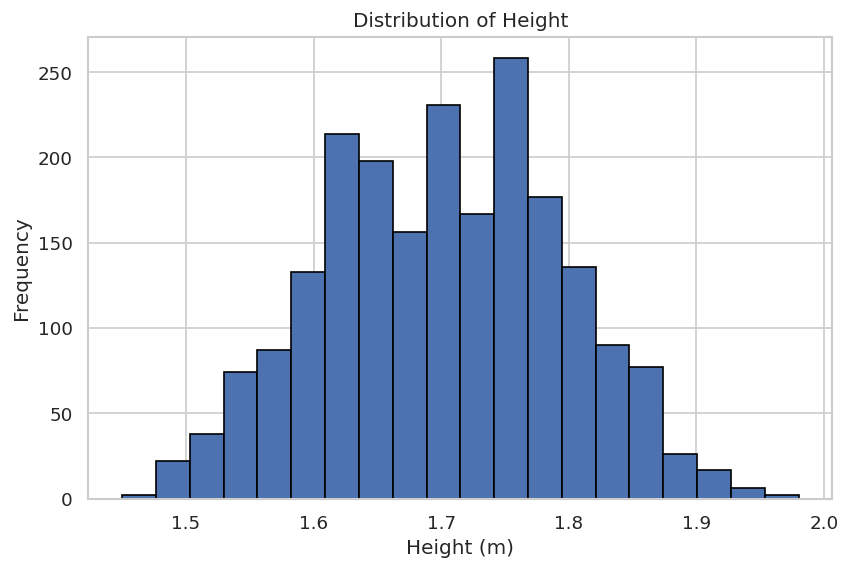

In [97]:
plt.figure(figsize=(8,5))

plt.hist(obesity["Height"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of Height")
plt.xlabel("Height (m)")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [98]:
print(obesity["Height"].describe())
print()
print("Skewness :", round(obesity["Height"].skew(),2))
print()
print("Kurtosis :", round(obesity["Height"].kurt(),2))

count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max         1.980000
Name: Height, dtype: float64

Skewness : -0.01

Kurtosis : -0.56


Interpretation

Height is generally expected to follow an approximately normal distribution. If the histogram appears bell-shaped and the skewness is close to zero, the height measurements are relatively balanced across participants. Any noticeable skewness or extreme values should be discussed.


6.3 Weight

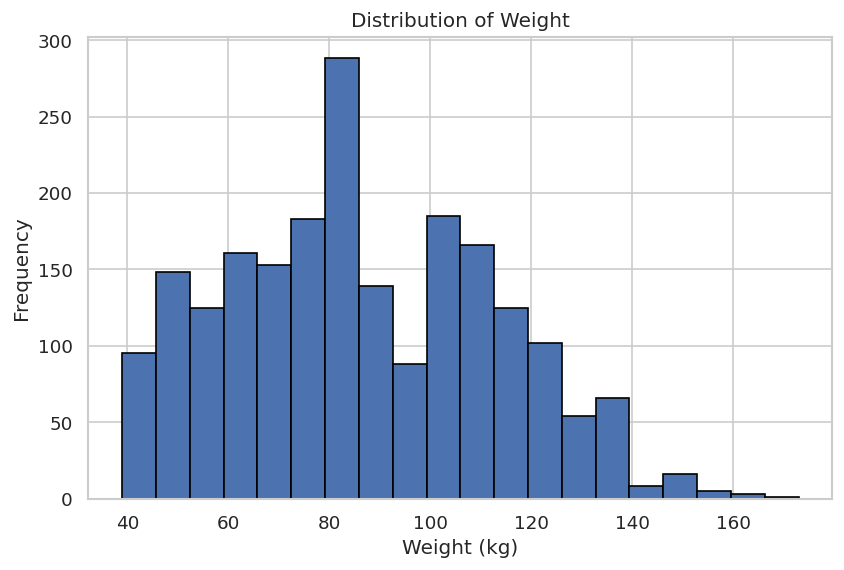

In [99]:
plt.figure(figsize=(8,5))

plt.hist(obesity["Weight"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.show()

In [100]:
print(obesity["Weight"].describe())
print()
print("Skewness :", round(obesity["Weight"].skew(),2))
print()
print("Kurtosis :", round(obesity["Weight"].kurt(),2))

count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64

Skewness : 0.26

Kurtosis : -0.7


Interpretation

Weight usually exhibits greater variation than height. A right-skewed distribution indicates that while most participants have moderate body weight, a smaller number have substantially higher weights. This is expected in an obesity-related dataset.

6.4 BMI

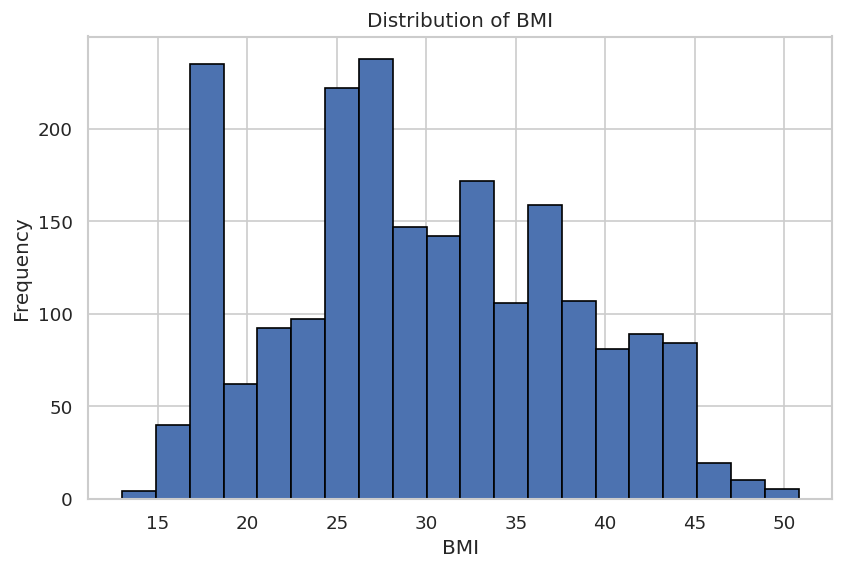

In [101]:
plt.figure(figsize=(8,5))

plt.hist(obesity["BMI"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [102]:
print(obesity["BMI"].describe())
print()
print("Skewness :", round(obesity["BMI"].skew(),2))
print()
print("Kurtosis :", round(obesity["BMI"].kurt(),2))

count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64

Skewness : 0.15

Kurtosis : -0.81


Interpretation

BMI is one of the most important indicators of obesity. The distribution helps identify whether participants are concentrated around normal BMI values or whether a substantial proportion falls into overweight and obesity categories.

6.5 Physical Activity (FAF)

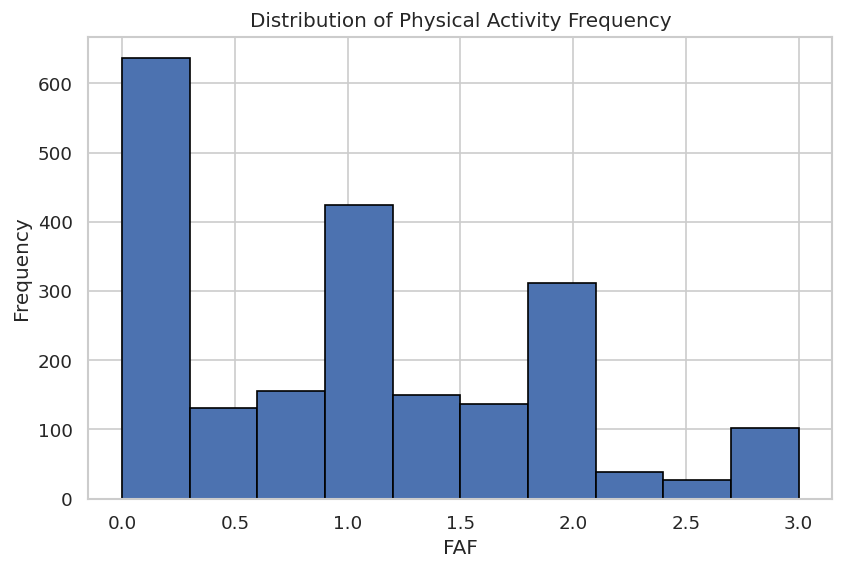

In [103]:
plt.figure(figsize=(8,5))

plt.hist(obesity["FAF"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Physical Activity Frequency")
plt.xlabel("FAF")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [104]:
print(obesity["FAF"].describe())
print()
print("Skewness :", round(obesity["FAF"].skew(),2))
print()
print("Kurtosis :", round(obesity["FAF"].kurt(),2))

count    2111.000000
mean        1.010298
std         0.850592
min         0.000000
25%         0.124505
50%         1.000000
75%         1.666678
max         3.000000
Name: FAF, dtype: float64

Skewness : 0.5

Kurtosis : -0.62


Interpretation

The distribution of physical activity frequency indicates participants' exercise habits. A concentration at lower values suggests that many participants engage in limited physical activity, which may be associated with obesity risk.

6.6 Water Intake (CH20)

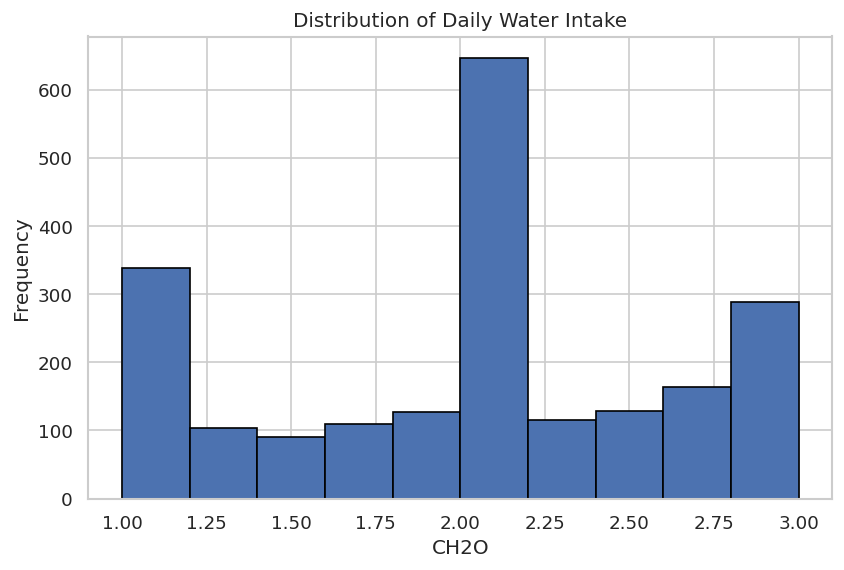

In [105]:
plt.figure(figsize=(8,5))

plt.hist(obesity["CH2O"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Daily Water Intake")
plt.xlabel("CH2O")
plt.ylabel("Frequency")

plt.show()

Summary Statistic

In [106]:
print(obesity["CH2O"].describe())
print()
print("Skewness :", round(obesity["CH2O"].skew(),2))
print()
print("Kurtosis :", round(obesity["CH2O"].kurt(),2))

count    2111.000000
mean        2.008011
std         0.612953
min         1.000000
25%         1.584812
50%         2.000000
75%         2.477420
max         3.000000
Name: CH2O, dtype: float64

Skewness : -0.1

Kurtosis : -0.88


Interpretation

Daily water intake shows how hydration habits vary across participants. A distribution concentrated around the middle suggests relatively consistent water consumption, while a skewed distribution indicates differences in drinking behaviour among individuals.

6.7 Distribution Summary Table

In [107]:
summary = pd.DataFrame({
    "Mean": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].mean(),
    "Median": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].median(),
    "Std": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].std(),
    "Skewness": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].skew(),
    "Kurtosis": obesity[["Age","Height","Weight","BMI","FAF","CH2O"]].kurt()
})

summary = summary.round(2)

summary

,Mean,Median,Std,Skewness,Kurtosis
Age,24.31,22.78,6.35,1.53,2.83
Height,1.70,1.70,0.09,-0.01,-0.56
Weight,86.59,83.00,26.19,0.26,-0.70
BMI,29.70,28.72,8.01,0.15,-0.81
FAF,1.01,1.00,0.85,0.50,-0.62
CH2O,2.01,2.00,0.61,-0.10,-0.88


6.8 Overall Distribution Summary

Overall, most numerical variables exhibit reasonable distributions without severe abnormalities. Height appears approximately normally distributed, whereas Weight and BMI show moderate right-skewness, reflecting the presence of overweight and obese participants. Lifestyle-related variables such as physical activity (FAF) and water intake (CH2O) display moderate variability. These findings suggest that the dataset is suitable for subsequent feature engineering and predictive modelling.

7. Correlation Analysis

In [108]:
corr = obesity.corr(numeric_only=True)

corr["Weight"].sort_values(ascending=False)

Weight    1.000000
BMI       0.934806
Height    0.463136
FCVC      0.216125
Age       0.202560
CH2O      0.200575
NCP       0.107469
FAF      -0.051436
TUE      -0.071561
Name: Weight, dtype: float64

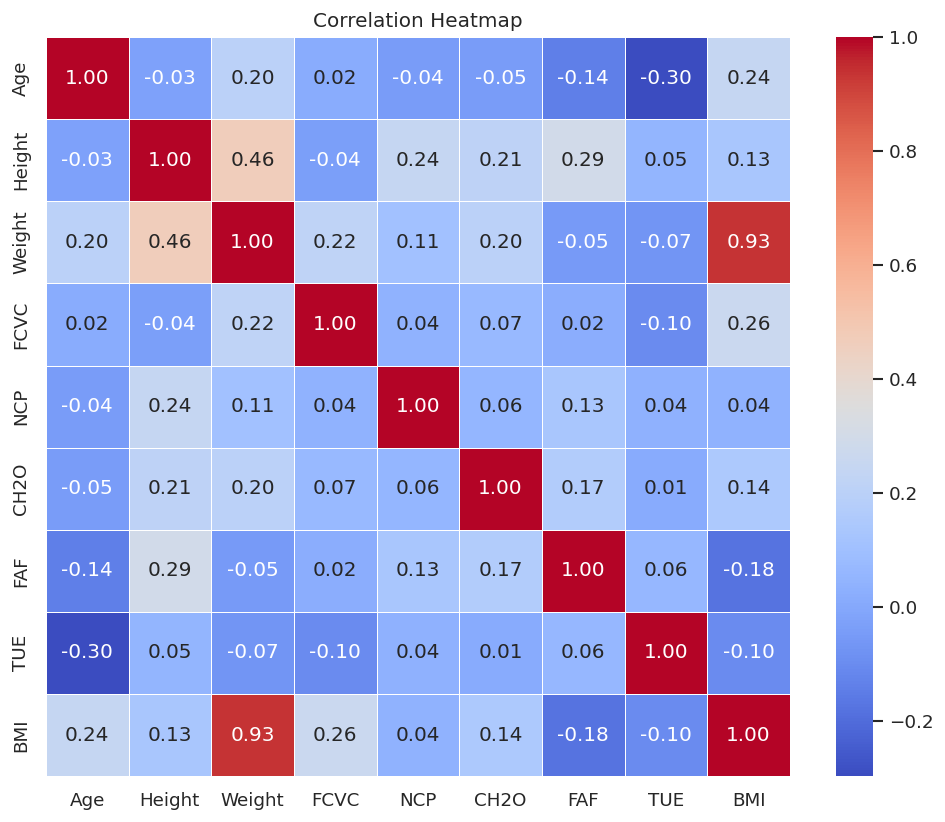

In [109]:
plt.figure(figsize=(10,8))

correlation = obesity.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

Report:
BMI is expected to be an important predictor of obesity level and will therefore be included in the predictive models.

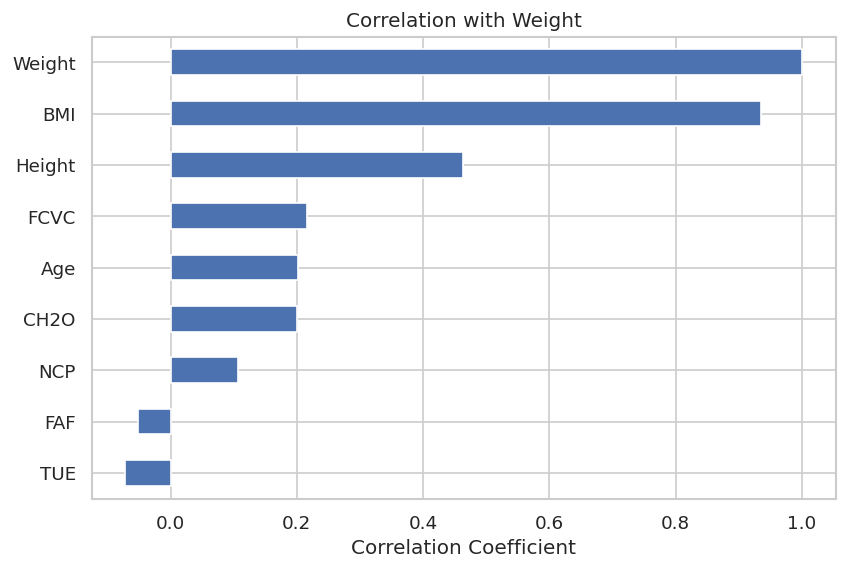

In [110]:
corr = obesity.corr(numeric_only=True)

corr_weight = corr["Weight"].sort_values()

plt.figure(figsize=(8,5))

corr_weight.plot(kind="barh")

plt.title("Correlation with Weight")

plt.xlabel("Correlation Coefficient")

plt.show()

Report:

1. Height shows a moderate positive correlation with Weight (r = 0.463), indicating that taller individuals generally tend to have higher body weight. However, the correlation is not strong, suggesting that other lifestyle factors also influence body weight.

2. FCVC has a weak positive correlation with Weight (r = 0.216), suggesting only a slight linear relationship. Further analysis is required to determine whether vegetable consumption has a meaningful effect on body weight.

Conclusion:

Based on the correlation analysis, Height has the strongest positive relationship with Weight among the numerical variables. Lifestyle-related variables such as vegetable consumption (FCVC), water intake (CH2O), and age exhibit only weak positive correlations, while physical activity (FAF) and technology usage (TUE) show very weak negative correlations. This suggests that body weight is likely influenced by multiple interacting factors rather than any single numerical variable.

8. Initial Business Insight

Preliminary analysis indicates that obesity is likely influenced by multiple factors rather than a single variable. Lifestyle behaviours such as physical activity, eating habits, and family history appear to contribute significantly and will be further examined during exploratory analysis and predictive modelling.

Data Preparation
- check missing values
- data cleaning - Rounding / Standardising Numeric Precision
- check duplicate records
- remove duplicate records
- detect outliers
- data transformation
- data standardisation

1. Missing Values

Missing value detection was performed to identify incomplete records in the dataset before data preprocessing. Missing values can reduce data quality and negatively affect the performance of machine learning models. Therefore, each attribute was examined using the isnull().sum() function in Pandas.

The results showed that there were no missing values in any of the dataset attributes. As a result, no imputation or missing value treatment was required, and the dataset was considered complete for further preprocessing and analysis.

In [111]:
# Check missing values
missing = obesity.isnull().sum()

# Calculate percentage of missing values
missing_percent = obesity.isnull().mean() * 100

# Create summary table
missing_obesity = pd.DataFrame({
    "Missing Value": missing,
    "Percentage (%)": missing_percent
})

missing_obesity

,Missing Value,Percentage (%)
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


2. Data Cleaning

In [112]:
obesity['Age'] = obesity['Age'].round(0).astype(int)         
obesity['Height'] = obesity['Height'].round(2)             
obesity['Weight'] = obesity['Weight'].round(2)                

for col in ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']:
    obesity[col] = obesity[col].round(0).astype(int)   

In [113]:
# Display data after rounding
print("Dataset after rounding:")
obesity[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].head(10)
obesity

Dataset after rounding:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21,1.62,64.00,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21,1.52,56.00,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23,1.80,77.00,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27,1.80,87.00,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22,1.78,89.80,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.41,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III,44.901475
2107,Female,22,1.75,133.74,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.741923
2108,Female,23,1.75,133.69,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.543817
2109,Female,24,1.74,133.35,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,44.071535


3. Duplicate Records

Duplicate record detection was performed to identify repeated observations in the dataset. Duplicate records may introduce bias and affect the accuracy of machine learning models by giving certain observations more influence than others. Therefore, the duplicated() function was used to identify duplicate rows in the dataset.

The analysis found duplicate records in the dataset. These duplicate entries were removed using the drop_duplicates() function to ensure that each observation was unique before proceeding with further data preprocessing.

In [114]:
# Check duplicate rows
duplicate = obesity.duplicated().sum()

print("Duplicate Rows:", duplicate)
print("Percentage:", duplicate / len(obesity) * 100)

Duplicate Rows: 27
Percentage: 1.27901468498342


In [115]:
# Remove duplicate rows
obesity = obesity.drop_duplicates().copy()

# Verify duplicate removal
duplicate = obesity.duplicated().sum()

print("Duplicate Rows:", duplicate)
print("Percentage:", duplicate / len(obesity) * 100)

Duplicate Rows: 0
Percentage: 0.0


In [116]:
print(obesity.shape)
print(obesity.duplicated().sum())

(2084, 18)
0


3. Outlier Detection
   
Outliers are extreme values that differ significantly from the rest of the data. Detecting outliers is important because they may affect the performance of machine learning models. In this project, boxplots were used to identify potential outliers in the numerical features.

Boxplots and the Interquartile Range (IQR) method were used to detect potential outliers in the numerical attributes. Although several outliers were identified, they were retained because they represent valid observations related to obesity levels rather than data entry errors. Removing these values could reduce the dataset's ability to represent real-world obesity conditions.

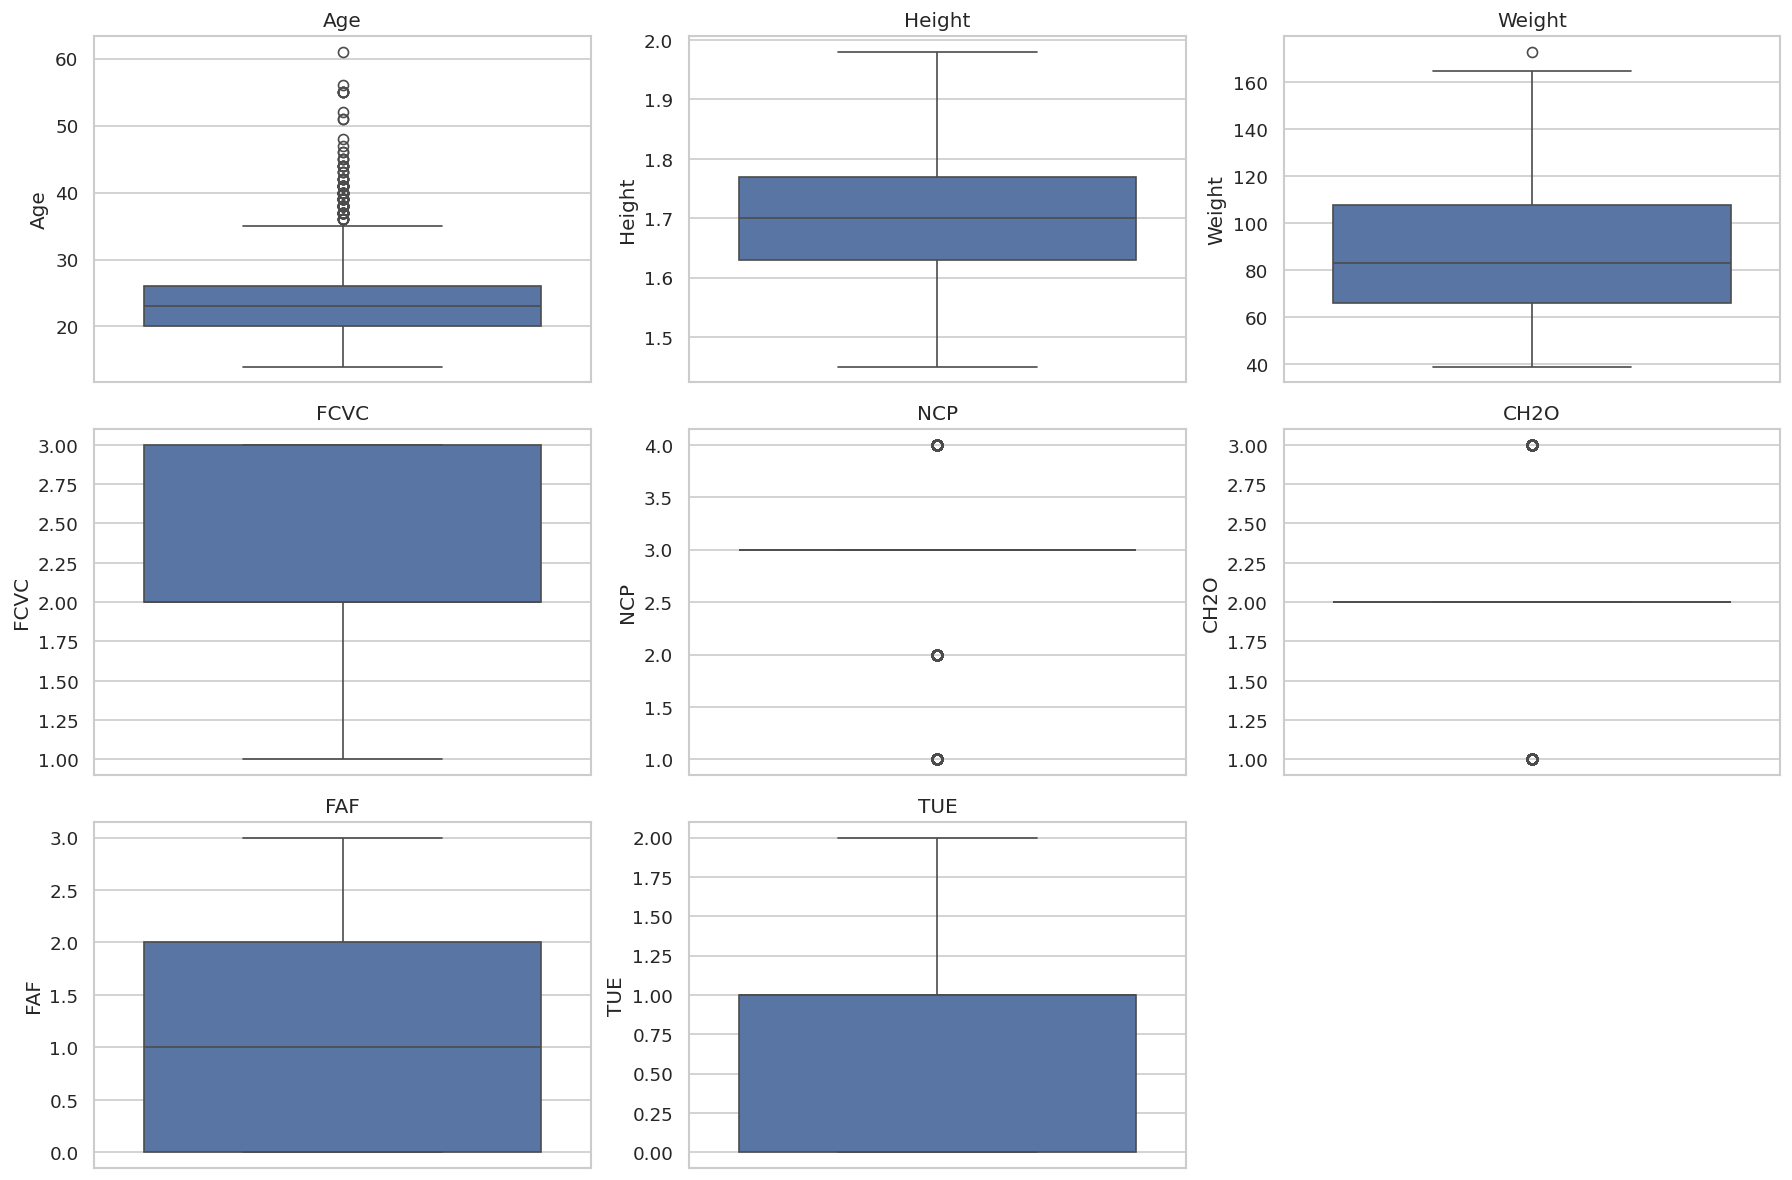

In [117]:
numerical_columns = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=obesity[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [118]:
print("Outlier Detection using IQR:\n")

for col in numerical_columns:
    Q1 = obesity[col].quantile(0.25)
    Q3 = obesity[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = obesity[(obesity[col] < lower) | (obesity[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Detection using IQR:

Age: 160 outliers
Height: 0 outliers
Weight: 1 outliers
FCVC: 0 outliers
NCP: 621 outliers
CH2O: 980 outliers
FAF: 0 outliers
TUE: 0 outliers


4. Data Transformation
   
Data transformation is performed to convert the dataset into a suitable format for machine learning algorithms. Since machine learning models require numerical input, categorical variables must be transformed into numerical values. In this project, Label Encoding was applied to all categorical attributes to ensure that the dataset is compatible with subsequent modelling processes.

Step 1: Identify categorical variables

In [119]:
categorical_columns = obesity.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


Step 2: Apply label encoding

In [120]:
# Keep an untouched copy of the original human-readable dataset
obesity_clean = obesity.copy()

# Create a separate dataset for modelling
obesity_model = obesity_clean.copy()

# Store a separate encoder for each categorical variable
encoders = {}

for column in categorical_columns:
    encoders[column] = LabelEncoder()
    obesity_model[column] = encoders[column].fit_transform(
        obesity_model[column]
    )

# The target variable gets its own encoder
target_encoder = encoders["NObeyesdad"]

# Use the encoded dataframe for modelling
obesity = obesity_model.copy()

print("Categorical variables encoded successfully.")
print("\nNObeyesdad encoding:")
for code, category in enumerate(target_encoder.classes_):
    print(f"{code}: {category}")

Categorical variables encoded successfully.

NObeyesdad encoding:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II


In [121]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,21,1.62,64.0,1,0,2,3,2,0,2,0,0,1,3,3,1,24.386526
1,0,21,1.52,56.0,1,0,3,3,2,1,3,1,3,0,2,3,1,24.238227
2,1,23,1.80,77.0,1,0,2,3,2,0,2,0,2,1,1,3,1,23.765432
3,1,27,1.80,87.0,0,0,3,3,2,0,2,0,2,0,1,4,5,26.851852
4,1,22,1.78,89.8,0,0,2,1,2,0,2,0,0,0,2,3,6,28.342381


In [122]:
print(obesity.dtypes)

Gender                              int64
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                                int64
NCP                                 int64
CAEC                                int64
SMOKE                               int64
CH2O                                int64
SCC                                 int64
FAF                                 int64
TUE                                 int64
CALC                                int64
MTRANS                              int64
NObeyesdad                          int64
BMI                               float64
dtype: object


5. Data Standardisation (Feature Scaling)

Feature scaling was performed to standardise the numerical variables so that they are on a similar scale before model training. Standardisation helps prevent features with larger numerical ranges from dominating those with smaller ranges and can improve the performance of many machine learning algorithms, such as K-Nearest Neighbours (KNN), Support Vector Machine (SVM), and Logistic Regression.

In this project, the StandardScaler technique was used to transform the numerical attributes to have a mean of approximately 0 and a standard deviation of approximately 1.

In [123]:
# Create StandardScaler object
scaler = StandardScaler()

# Select only continuous numerical features
scale_columns = [
    "Age",
    "Height",
    "Weight",
    "BMI",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

# Apply feature scaling
obesity[scale_columns] = scaler.fit_transform(obesity[scale_columns])

print("Feature scaling completed successfully.")


Feature scaling completed successfully.


In [124]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,-0.526361,-0.885896,-0.873773,1,0,-0.729935,0.372487,2,0,-0.016796,0,-1.122977,0.491540,3,3,1,-0.671335
1,0,-0.526361,-1.957839,-1.179235,1,0,0.981183,0.372487,2,1,1.441672,1,2.215516,-0.993054,2,3,1,-0.689817
2,1,-0.212906,1.043601,-0.377396,1,0,-0.729935,0.372487,2,0,-0.016796,0,1.102685,0.491540,1,3,1,-0.748741
3,1,0.414004,1.043601,0.004432,0,0,0.981183,0.372487,2,0,-0.016796,0,1.102685,-0.993054,1,4,5,-0.364088
4,1,-0.369633,0.829213,0.111344,0,0,-0.729935,-2.135630,2,0,-0.016796,0,-1.122977,-0.993054,2,3,6,-0.178326


In [125]:
# Use the untouched human-readable dataset for EDA and visualisation
obesity_visual = obesity_clean.copy()

# Remove duplicate rows for visualisation only
before_count = len(obesity_visual)

obesity_visual = obesity_visual.drop_duplicates().reset_index(drop=True)

after_count = len(obesity_visual)

print("Human-readable dataset prepared for visualisation.")
print(f"Duplicates removed: {before_count - after_count}")
print(f"Final rows: {after_count}")

Human-readable dataset prepared for visualisation.
Duplicates removed: 0
Final rows: 2084


In [126]:
obesity_visual[["Gender","Age", "Weight", "BMI"]].head()

,Gender,Age,Weight,BMI
0,Female,21,64.0,24.386526
1,Female,21,56.0,24.238227
2,Male,23,77.0,23.765432
3,Male,27,87.0,26.851852
4,Male,22,89.8,28.342381


20 Type of Data Analysis

In [127]:
import squarify

obesity_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II",
]

obesity_plot = obesity_visual.copy() if "obesity_visual" in locals() else obesity.copy()

if obesity_plot["NObeyesdad"].dtype in ["int64", "float64"]:
    obesity_plot["NObeyesdad"] = obesity_plot["NObeyesdad"].map(target_mapping)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

Physical Traits & Target

1.Height vs Weight 

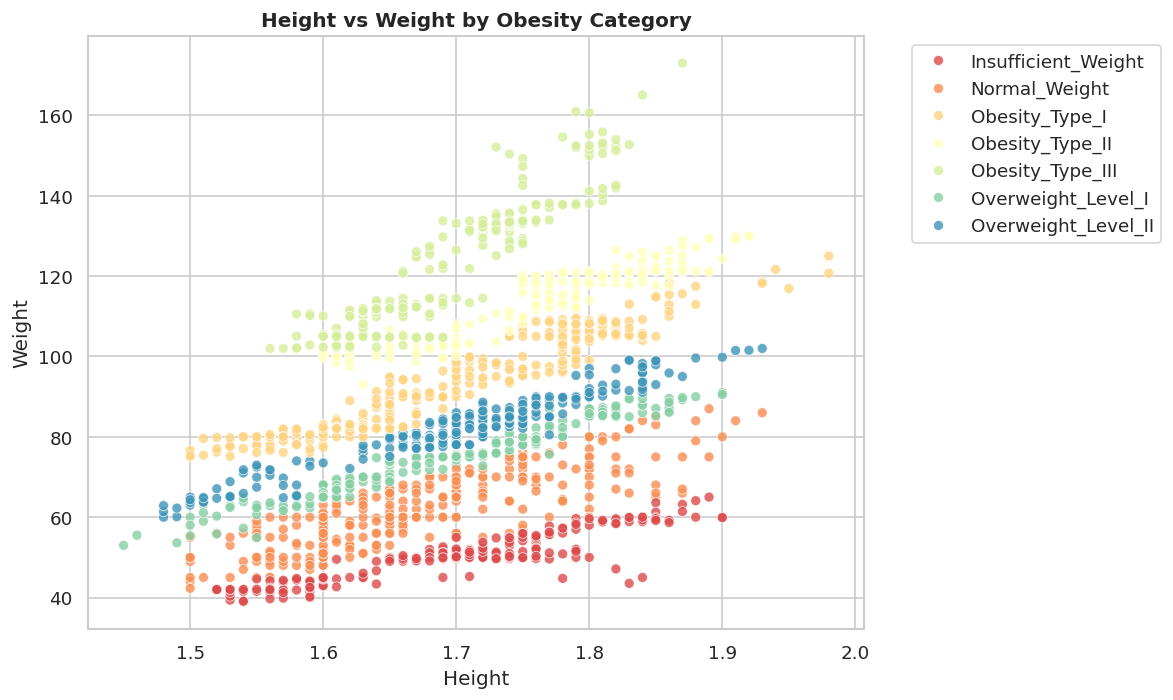

In [128]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=obesity_plot,
    x="Height",
    y="Weight",
    hue="NObeyesdad",
    hue_order=obesity_order,
    palette="Spectral",
    alpha=0.8,
)
plt.title(
    "Height vs Weight by Obesity Category", fontsize=12, fontweight="bold"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

2. Age Distribution across Obesity Levels

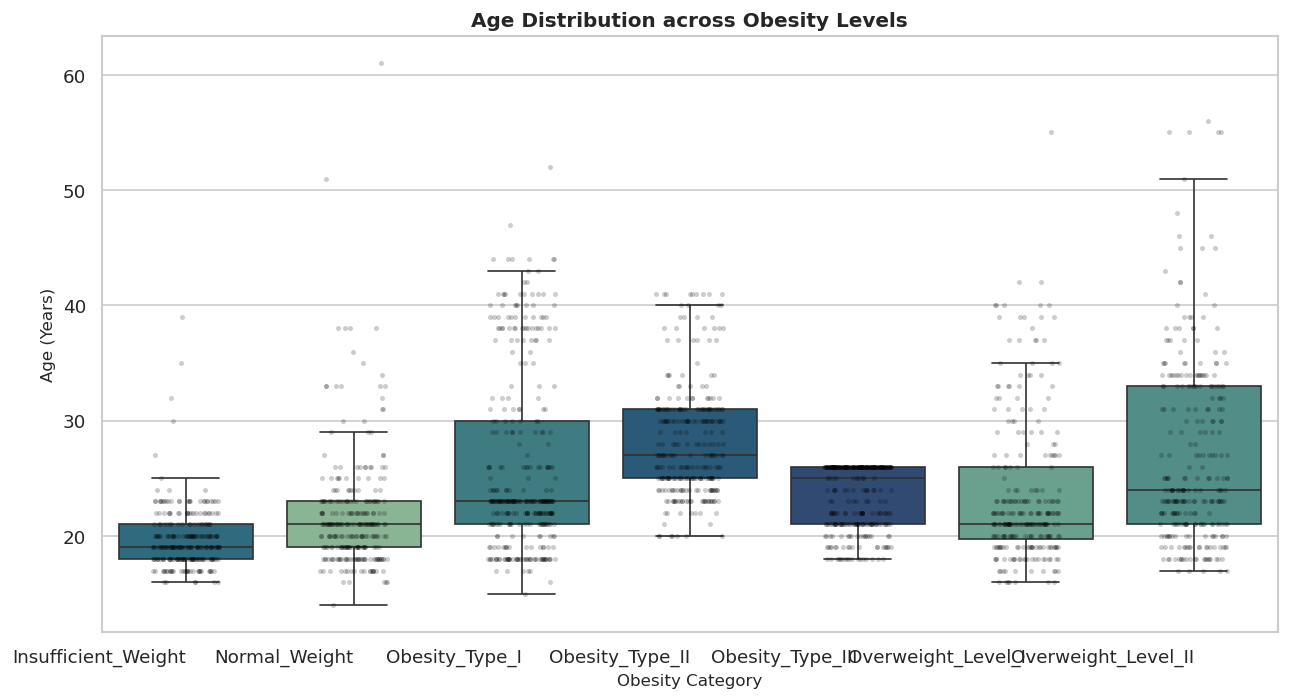

In [129]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="Age",
    hue="NObeyesdad",  
    order=obesity_order,
    palette="crest",
    fliersize=0,
    legend=False,
)

sns.stripplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="Age",
    order=obesity_order,
    color="black",
    alpha=0.2,
    jitter=0.2,
    size=3,
)

plt.title(
    "Age Distribution across Obesity Levels", fontsize=12, fontweight="bold"
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Age (Years)", fontsize=10)

plt.xticks(rotation=0, ha="right")

plt.tight_layout()
plt.show()

3.Gender Proportion within Each Obesity Level (100% Stacked Bar)

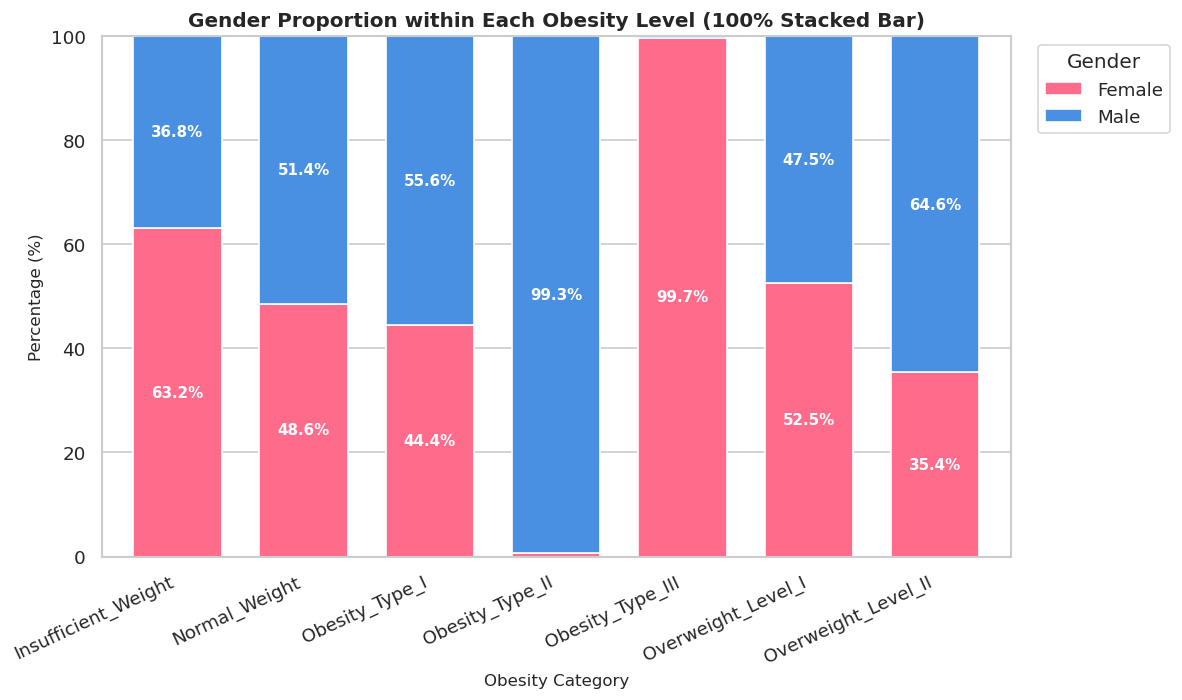

In [130]:
ct_gender = pd.crosstab(
    obesity_plot["NObeyesdad"], obesity_plot["Gender"]
).reindex(obesity_order)
ct_gender = ct_gender[["Female", "Male"]].apply(
    lambda r: r / r.sum() * 100, axis=1
)

custom_colors = ["#FF6B8B", "#4A90E2"]

ax = ct_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=custom_colors,  
    edgecolor="white",
    width=0.7,
)

plt.title(
    "Gender Proportion within Each Obesity Level (100% Stacked Bar)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Percentage (%)", fontsize=10)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    if height > 5: 
        ax.annotate(
            f"{height:.1f}%",
            (x + width / 2, y + height / 2),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

4. Impact of Family History on BMI Density Distribution

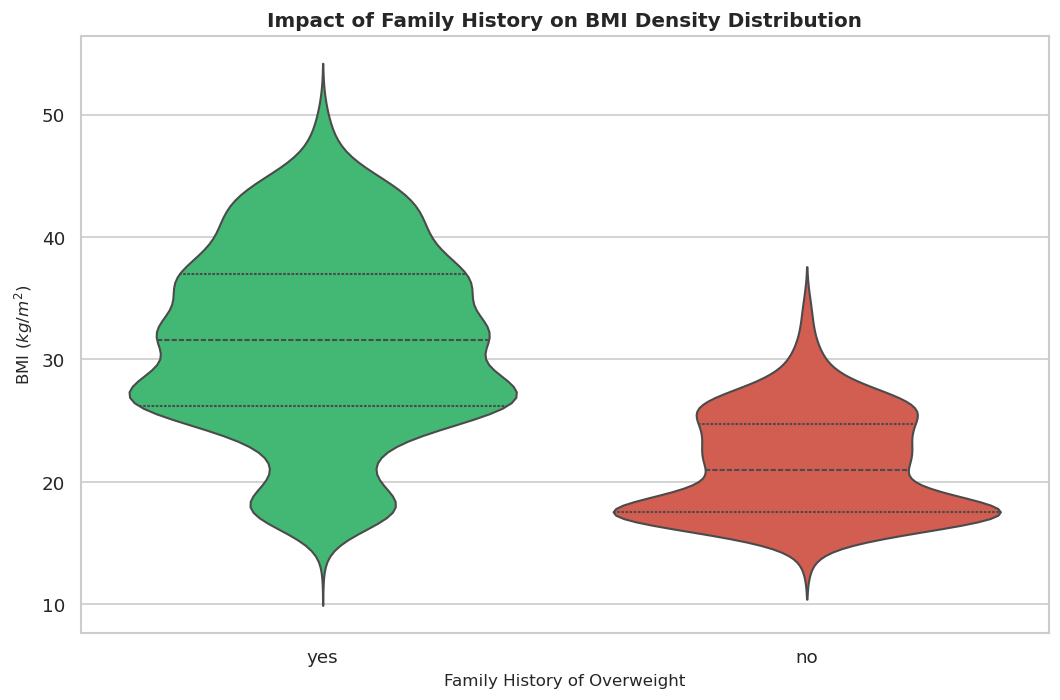

In [131]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=obesity_plot,
    x="family_history_with_overweight",
    y="BMI",
    hue="family_history_with_overweight", 
    palette=["#2ECC71", "#E74C3C"],  
    inner="quartile",  
    legend=False,
)

plt.title(
    "Impact of Family History on BMI Density Distribution",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Family History of Overweight", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)

plt.tight_layout()
plt.show()

5. Vegetable Consumption Frequency (FCVC) across Obesity Levels

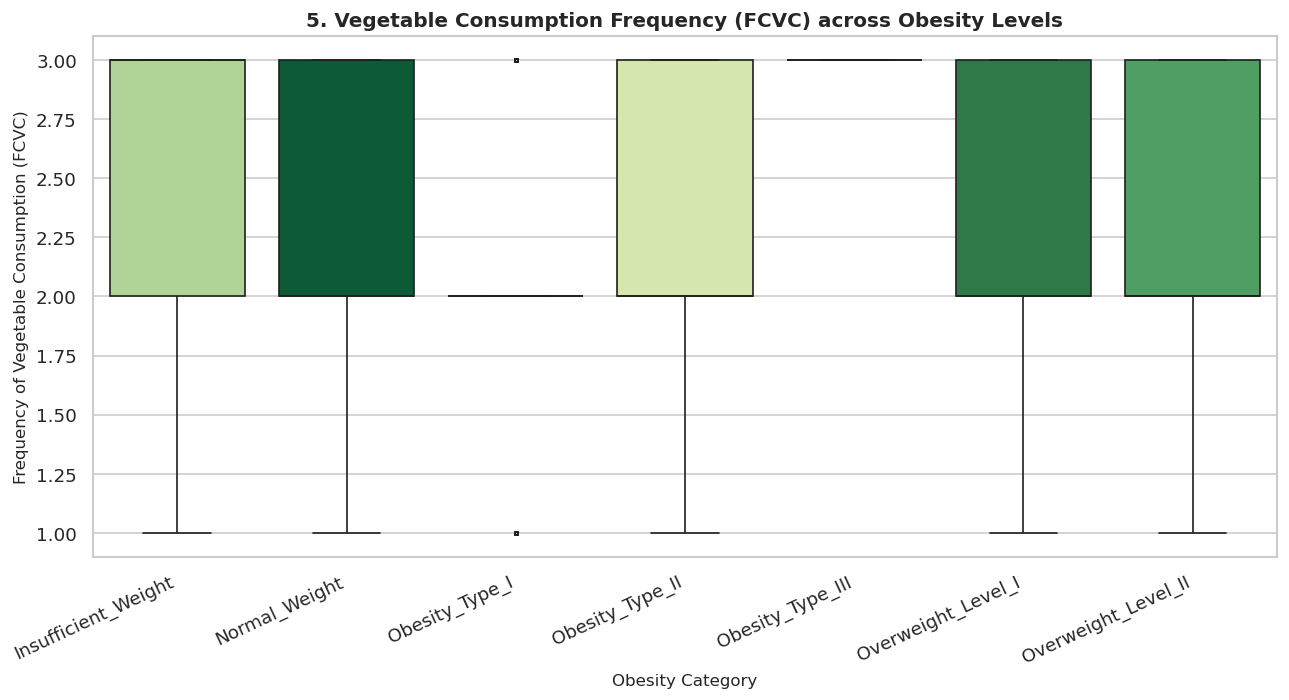

In [132]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=obesity_plot,
    x="NObeyesdad",
    y="FCVC",
    hue="NObeyesdad", 
    order=obesity_order,
    palette="YlGn_r",  
    fliersize=2,
    legend=False,
)

plt.title(
    "5. Vegetable Consumption Frequency (FCVC) across Obesity Levels",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Obesity Category", fontsize=10)
plt.ylabel("Frequency of Vegetable Consumption (FCVC)", fontsize=10)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

6. Interaction Effect: Main Meals (NCP) & High-Calorie Food (FAVC) on BMI

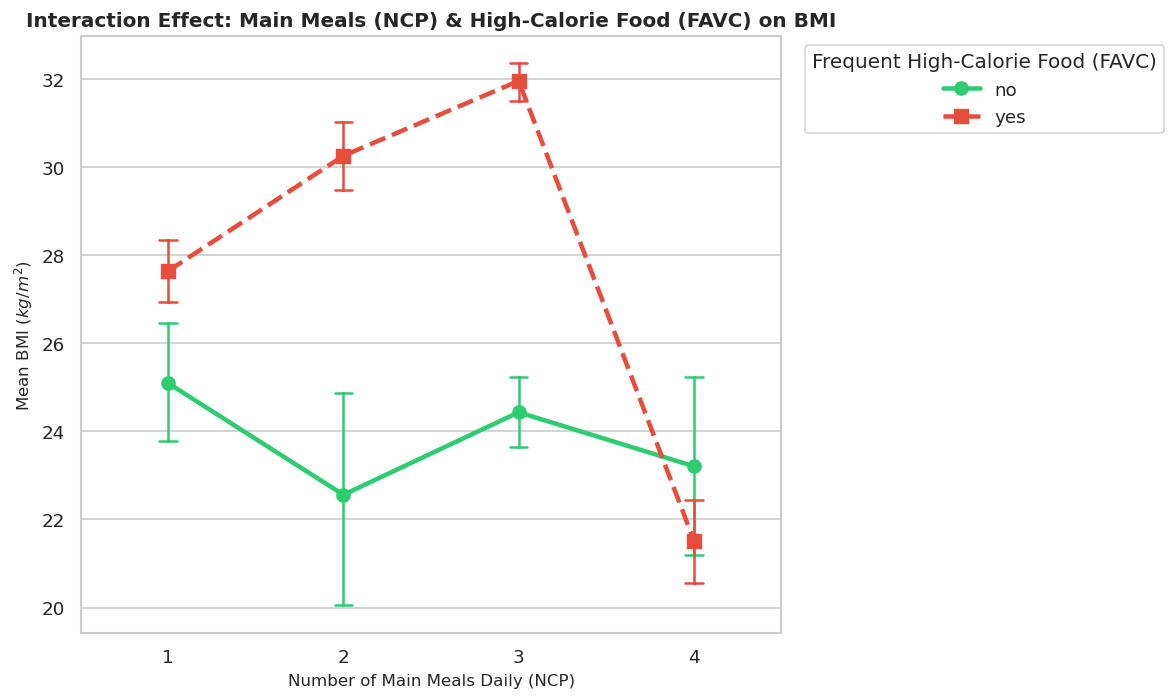

In [133]:
plt.figure(figsize=(10, 6))

sns.pointplot(
    data=obesity_plot,
    x="NCP",
    y="BMI",
    hue="FAVC",
    palette=["#2ECC71", "#E74C3C"],  
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1, 
    err_kws={"linewidth": 1.5},
)

plt.title(
    "Interaction Effect: Main Meals (NCP) & High-Calorie Food (FAVC) on BMI",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Main Meals Daily (NCP)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)
plt.legend(
    title="Frequent High-Calorie Food (FAVC)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

7. Crosstab Heatmap: Snack Consumption (CAEC) vs Obesity Levels

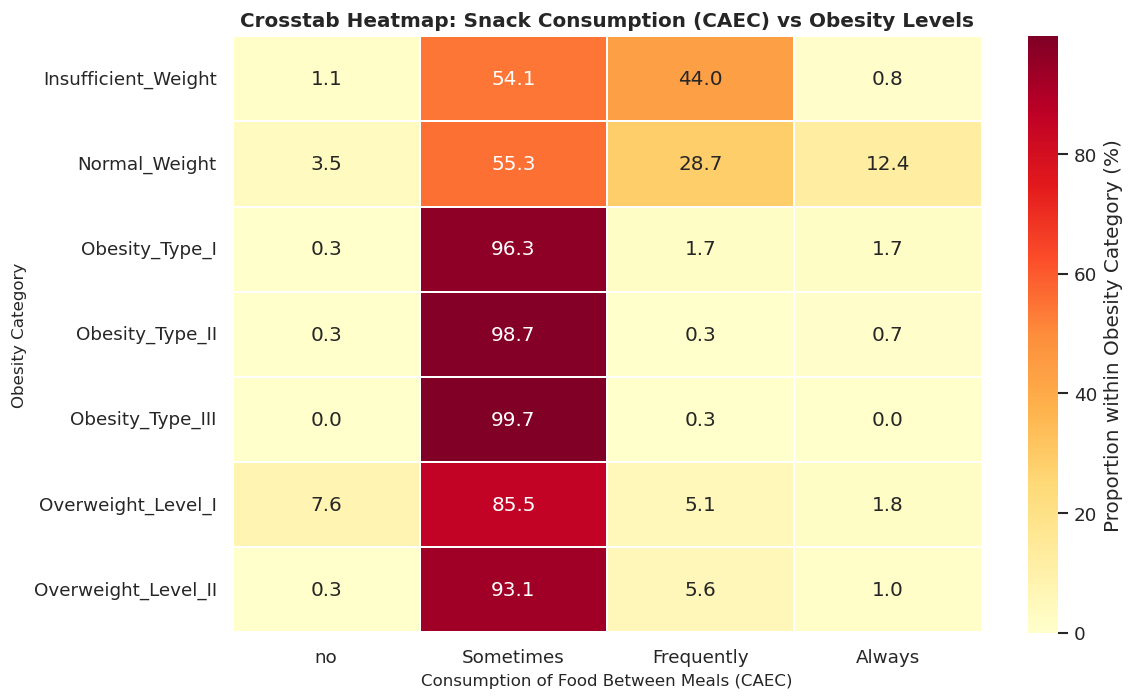

In [134]:
caec_order = ["no", "Sometimes", "Frequently", "Always"]

ct_caec = pd.crosstab(
    obesity_plot["NObeyesdad"],
    obesity_plot["CAEC"],
    normalize="index",  
) * 100

ct_caec = ct_caec.reindex(index=obesity_order, columns=caec_order).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    ct_caec,
    annot=True,  
    fmt=".1f", 
    cmap="YlOrRd",  
    cbar_kws={"label": "Proportion within Obesity Category (%)"},
    linewidths=1,
)

plt.title(
    "Crosstab Heatmap: Snack Consumption (CAEC) vs Obesity Levels",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Consumption of Food Between Meals (CAEC)", fontsize=10)
plt.ylabel("Obesity Category", fontsize=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

8. Daily Water Consumption (CH2O) Density Distribution Across Key Categories

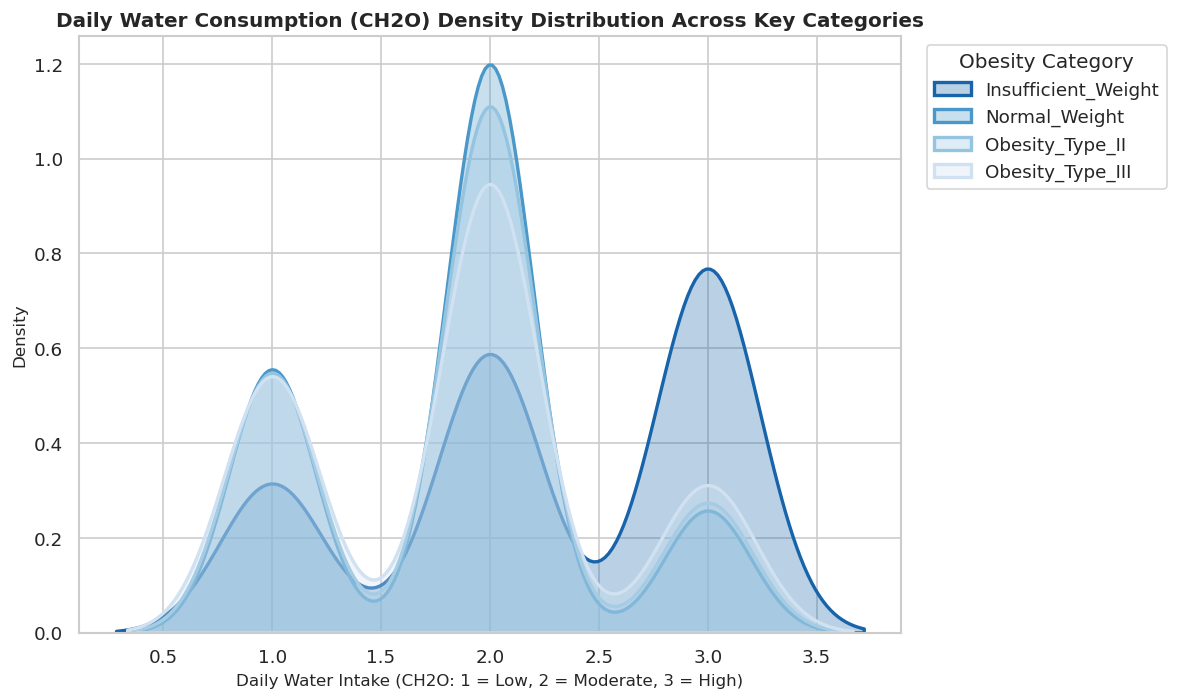

In [135]:
target_categories = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_II",
    "Obesity_Type_III",
]
obesity_kde = obesity_plot[
    obesity_plot["NObeyesdad"].isin(target_categories)
].copy()

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=obesity_kde,
    x="CH2O",
    hue="NObeyesdad",
    hue_order=target_categories,
    palette="Blues",  
    fill=True,
    common_norm=False,  
    alpha=0.3,
    linewidth=2,
)

plt.title(
    "Daily Water Consumption (CH2O) Density Distribution Across Key Categories",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Daily Water Intake (CH2O: 1 = Low, 2 = Moderate, 3 = High)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(
    title="Obesity Category",
    labels=target_categories,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

9. Alcohol Consumption Frequency (CALC) vs Mean BMI (with 95% CI)

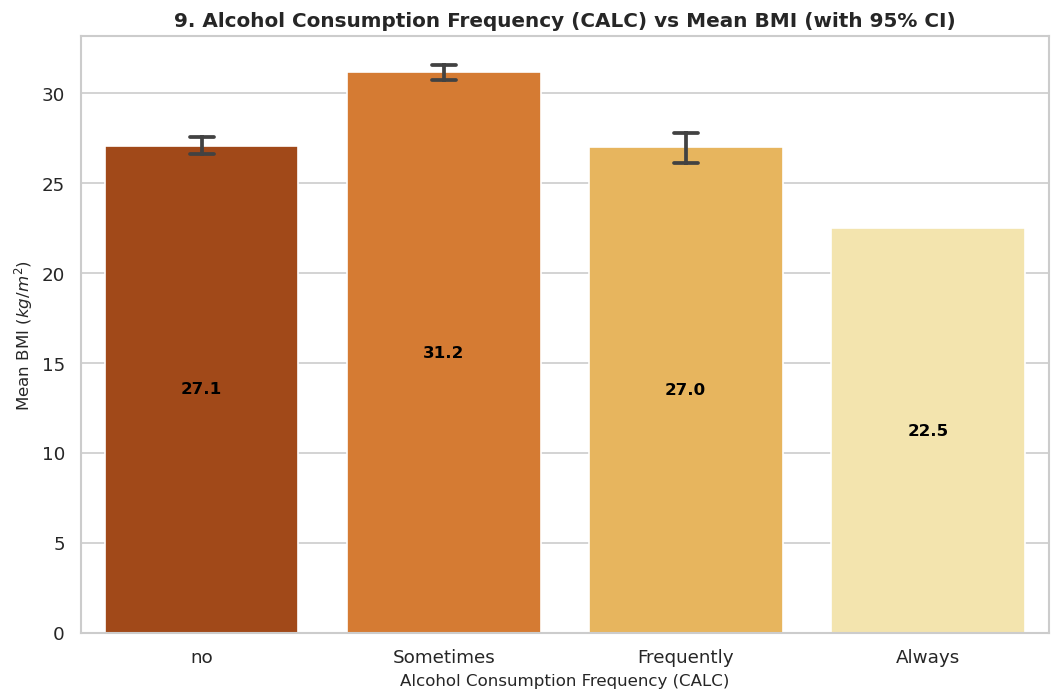

In [136]:
calc_order = ["no", "Sometimes", "Frequently", "Always"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=obesity_plot,
    x="CALC",
    y="BMI",
    hue="CALC", 
    order=calc_order,
    palette="YlOrBr_r",
    errorbar=("ci", 95), 
    capsize=0.1, 
    legend=False,
)

plt.title(
    "9. Alcohol Consumption Frequency (CALC) vs Mean BMI (with 95% CI)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Alcohol Consumption Frequency (CALC)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.1f}",
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            fontsize=10,
        )

plt.tight_layout()
plt.show()

10. Multifaceted Impact: Physical Activity (FAF) vs Tech Use (TUE) on BMI by Gender

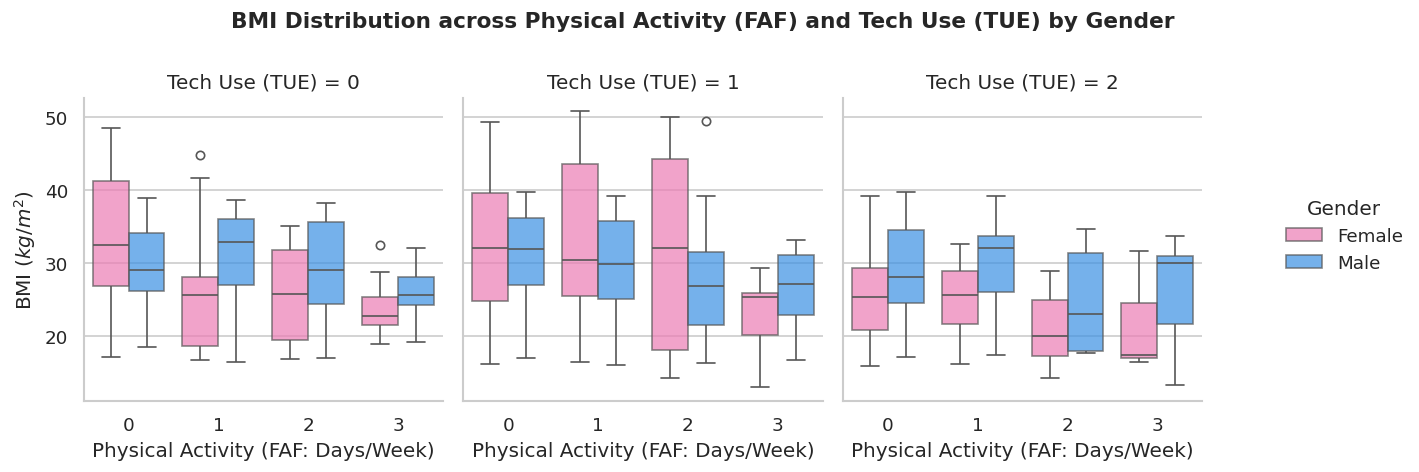

In [137]:
g = sns.catplot(
    data=obesity_plot,
    x="FAF",
    y="BMI",
    hue="Gender",
    col="TUE", 
    kind="box",
    palette={"Female": "#FF69B4", "Male": "#1E90FF"},
    height=4,
    aspect=0.9,
    boxprops={"alpha": 0.7},
)

g.fig.subplots_adjust(top=0.8, right=0.85)
g.fig.suptitle(
    "BMI Distribution across Physical Activity (FAF) and Tech Use (TUE) by Gender",
    fontsize=13,
    fontweight="bold",
)
g.set_axis_labels("Physical Activity (FAF: Days/Week)", "BMI ($kg/m^2$)")
g.set_titles("Tech Use (TUE) = {col_name}")

plt.show()

11. Physical Activity (FAF) vs BMI across Family History of Overweight

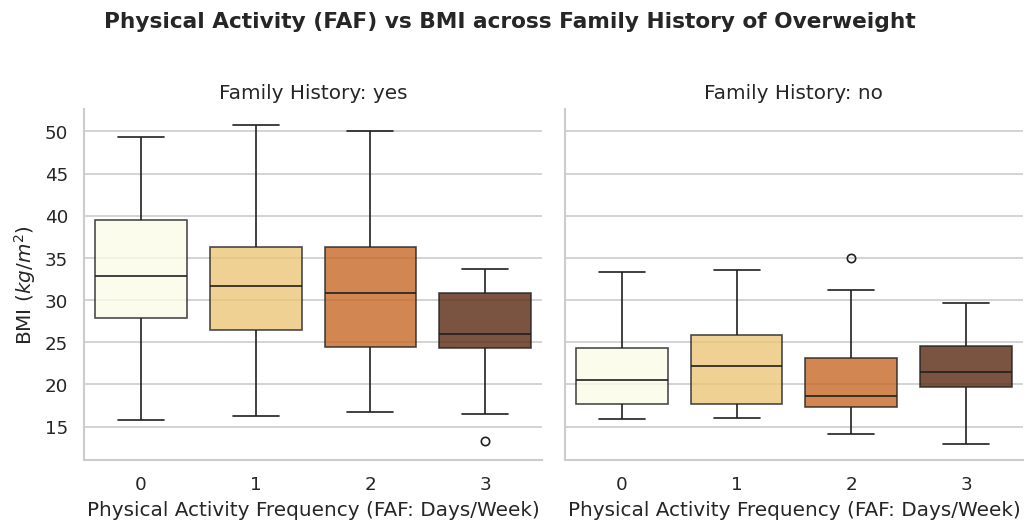

In [138]:
g = sns.catplot(
    data=obesity_plot,
    x="FAF",
    y="BMI",
    hue="FAF",
    col="family_history_with_overweight", 
    kind="box",
    palette="YlOrBr",  
    height=4.5,
    aspect=0.95,
    boxprops={"alpha": 0.8},
    legend=False,
)

g.fig.subplots_adjust(top=0.8, right=1.0)

g.fig.suptitle(
    "Physical Activity (FAF) vs BMI across Family History of Overweight",
    fontsize=13,
    fontweight="bold",
)
g.set_axis_labels("Physical Activity Frequency (FAF: Days/Week)", "BMI ($kg/m^2$)")
g.set_titles("Family History: {col_name}")

plt.show()

12. Average Physical Activity Frequency (FAF) by Transportation Method (MTRANS)

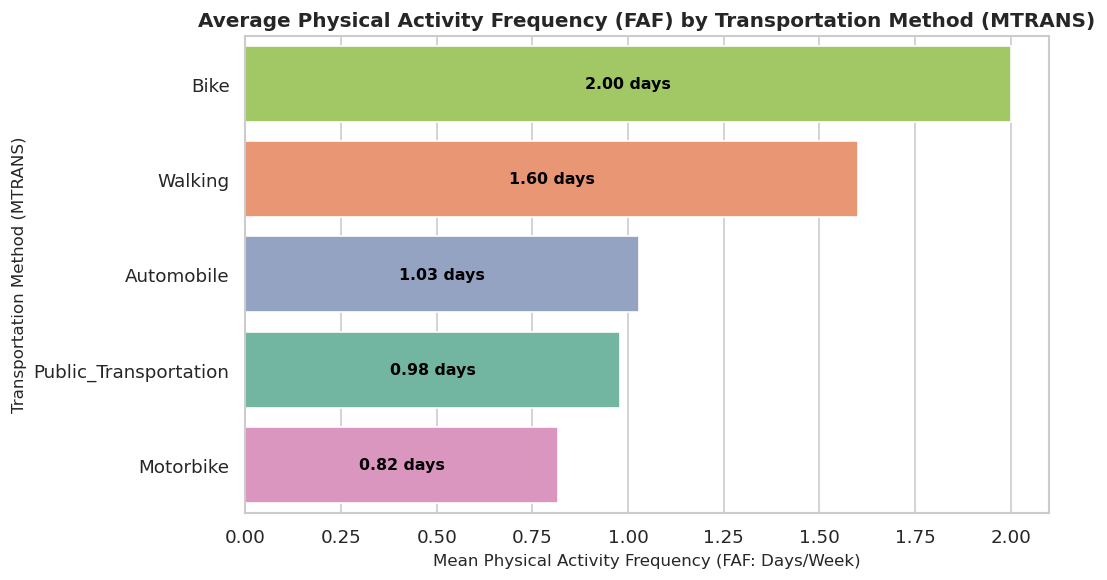

In [139]:
mtrans_order = (
    obesity_plot.groupby("MTRANS")["FAF"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=obesity_plot,
    x="FAF",
    y="MTRANS",
    hue="MTRANS",
    order=mtrans_order,
    palette="Set2", 
    errorbar=None,
    capsize=0.15,
    legend=False,
)

plt.title(
    "Average Physical Activity Frequency (FAF) by Transportation Method (MTRANS)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Mean Physical Activity Frequency (FAF: Days/Week)", fontsize=10)
plt.ylabel("Transportation Method (MTRANS)", fontsize=10)

for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.annotate(
            f"{width:.2f} days",
            (width / 2.0, p.get_y() + p.get_height() / 2.0),
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            fontsize=9.5,
        )

plt.tight_layout()
plt.show()

13. Combined Impact of Calorie Monitoring (SCC) & Smoking (SMOKE) on BMI

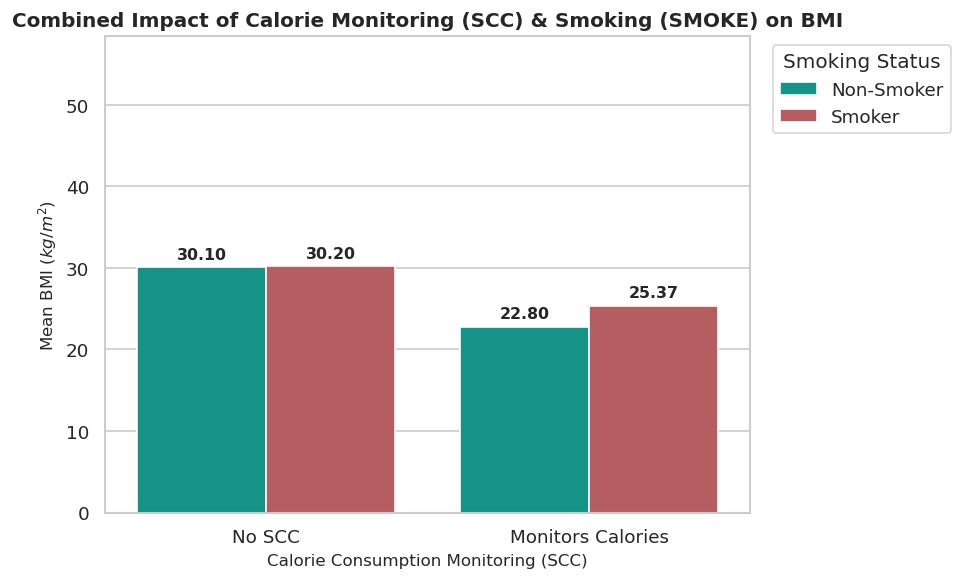

In [140]:
scc_map = {0: "No SCC", 1: "Monitors Calories (SCC)", "no": "No SCC", "yes": "Monitors Calories"}
smoke_map = {0: "Non-Smoker", 1: "Smoker", "no": "Non-Smoker", "yes": "Smoker"}

if "SCC" in obesity_plot.columns:
    obesity_plot["SCC_label"] = obesity_plot["SCC"].replace(scc_map)
if "SMOKE" in obesity_plot.columns:
    obesity_plot["SMOKE_label"] = obesity_plot["SMOKE"].replace(smoke_map)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=obesity_plot,
    x="SCC_label",
    y="BMI",
    hue="SMOKE_label",
    palette={"Non-Smoker": "#00A896", "Smoker": "#C44E52"},  
    errorbar=None,  
    capsize=0.1,
)

plt.title(
    "Combined Impact of Calorie Monitoring (SCC) & Smoking (SMOKE) on BMI",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Calorie Consumption Monitoring (SCC)", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontweight="bold",
            fontsize=9.5,
        )

plt.legend(title="Smoking Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, obesity_plot["BMI"].max() * 1.15) 

plt.tight_layout()
plt.show()

14. Transportation Method Disparities between Extreme Weight Groups

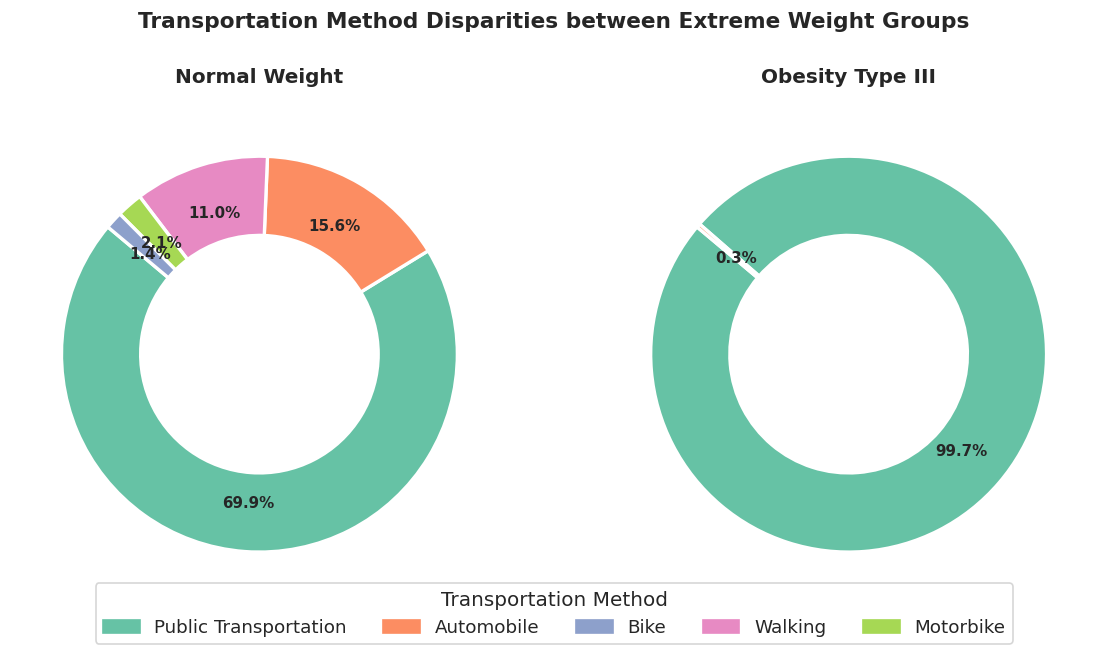

In [141]:
normal_data = obesity_plot[obesity_plot["NObeyesdad"].astype(str).str.contains("Normal", case=False, na=False)]
obesity_data = obesity_plot[obesity_plot["NObeyesdad"].astype(str).str.contains("Type_III|Type III", case=False, na=False)]

normal_counts = normal_data["MTRANS"].value_counts()
obesity_counts = obesity_data["MTRANS"].value_counts()

all_categories = list(set(normal_counts.index).union(set(obesity_counts.index)))
colors = sns.color_palette("Set2", len(all_categories))
color_map = dict(zip(all_categories, colors))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

wedges1, texts1, autotexts1 = axes[0].pie(
    normal_counts,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=[color_map[cat] for cat in normal_counts.index],
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
axes[0].set_title("Normal Weight", fontsize=12, fontweight="bold", pad=15)

wedges2, texts2, autotexts2 = axes[1].pie(
    obesity_counts,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=[color_map[cat] for cat in obesity_counts.index],
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
axes[1].set_title("Obesity Type III", fontsize=12, fontweight="bold", pad=15)

for autotext in autotexts1 + autotexts2:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

legend_labels = [cat.replace("_", " ") for cat in all_categories]
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[cat]) for cat in all_categories]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Transportation Method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=min(len(all_categories), 5),
    frameon=True,
)

fig.suptitle(
    "Transportation Method Disparities between Extreme Weight Groups",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

15. Dual Effect of Gender & Alcohol Consumption (CALC) on BMI

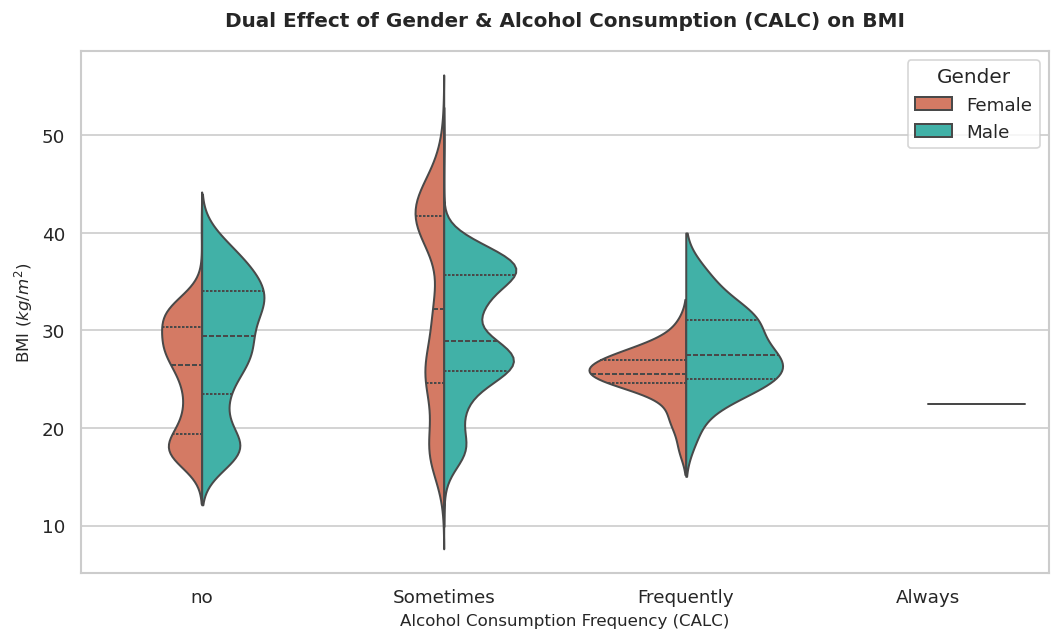

In [142]:
plt.figure(figsize=(9, 5.5))

calc_order = ["no", "Sometimes", "Frequently", "Always"]

existing_order = [c for c in calc_order if c in obesity_plot["CALC"].unique()]

sns.violinplot(
    data=obesity_plot,
    x="CALC",
    y="BMI",
    hue="Gender",
    order=existing_order,
    palette={"Female": "#E76F51", "Male": "#2EC4B6"},
    split=True, 
    inner="quartile",  
    linewidth=1.2,
)

plt.title(
    "Dual Effect of Gender & Alcohol Consumption (CALC) on BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Alcohol Consumption Frequency (CALC)", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)
plt.legend(title="Gender", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

16. Obesity Tier Composition by Smoking Status (SMOKE)

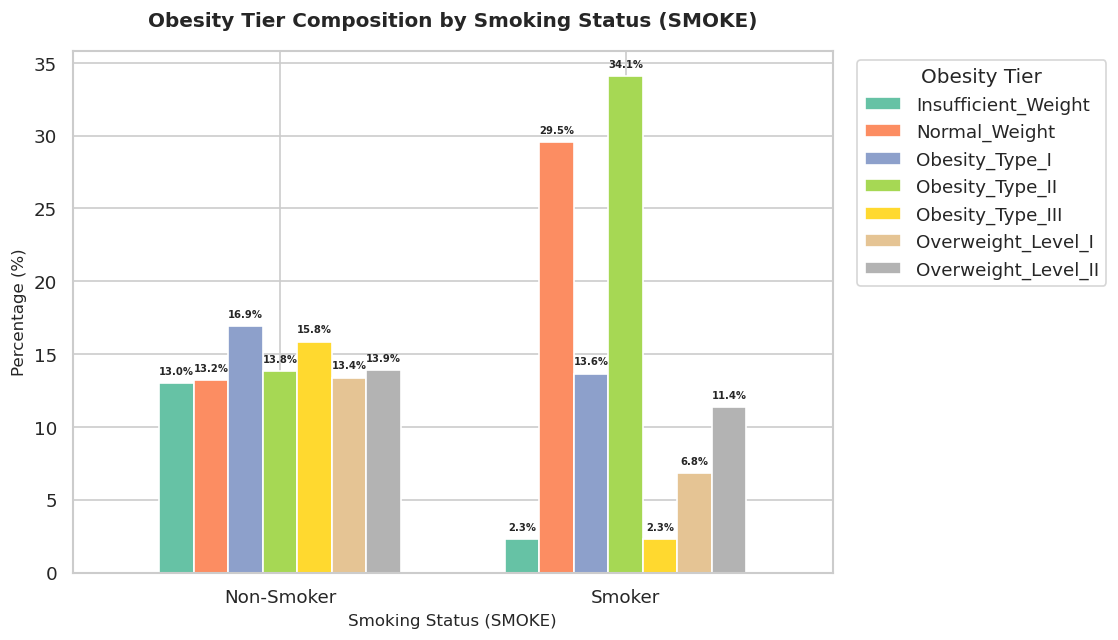

In [143]:
smoke_cross = (
    pd.crosstab(
        obesity_plot["SMOKE"], obesity_plot["NObeyesdad"], normalize="index"
    )
    * 100
)

ax = smoke_cross.plot(
    kind="bar", figsize=(9.5, 5.5), colormap="Set2", width=0.7, edgecolor="white"
)

plt.title(
    "Obesity Tier Composition by Smoking Status (SMOKE)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Smoking Status (SMOKE)", fontsize=10)
plt.ylabel("Percentage (%)", fontsize=10)
plt.xticks(ticks=[0, 1], labels=["Non-Smoker", "Smoker"], rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 1.5:  
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height + 0.5),
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
        )

plt.legend(
    title="Obesity Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)
plt.tight_layout()
plt.show()

17. Interaction Effect: Family History & High-Caloric Food (FAVC) on BMI

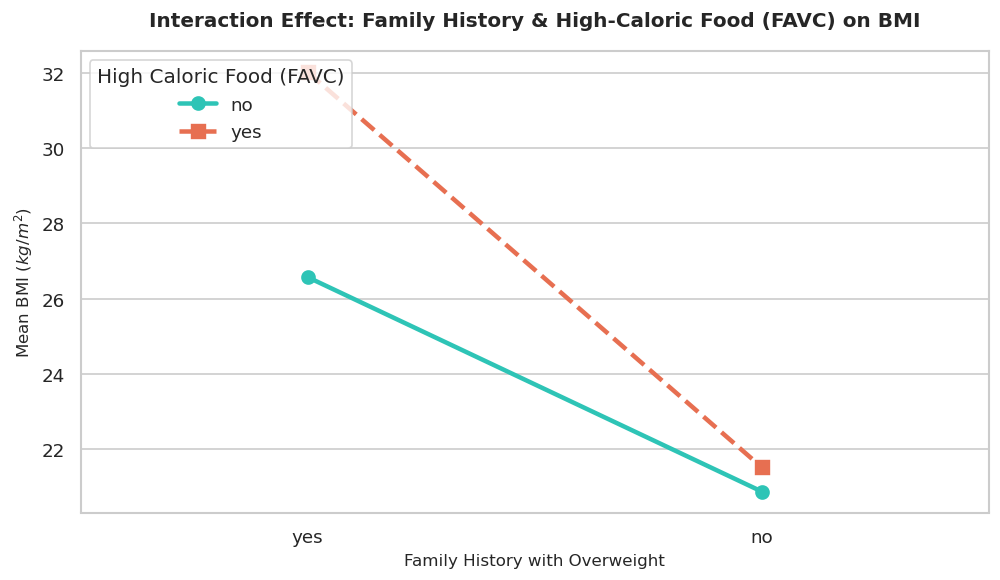

In [144]:
plt.figure(figsize=(8.5, 5))

sns.pointplot(
    data=obesity_plot,
    x="family_history_with_overweight",
    y="BMI",
    hue="FAVC",
    palette={"yes": "#E76F51", "no": "#2EC4B6"},
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1,
    errorbar=None,
)

plt.title(
    "Interaction Effect: Family History & High-Caloric Food (FAVC) on BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Family History with Overweight", fontsize=10)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)
plt.legend(title="High Caloric Food (FAVC)", loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

18. Cumulative Risk Factor Score vs. Average BMI

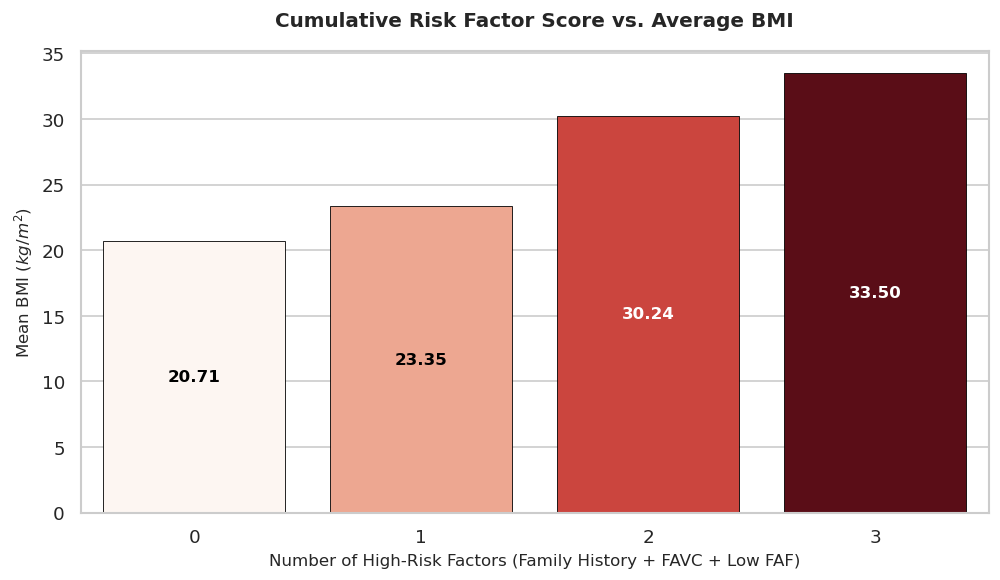

In [145]:
risk_df = obesity_plot.copy()
risk_df["Risk_Score"] = (
    (risk_df["family_history_with_overweight"] == "yes").astype(int)
    + (risk_df["FAVC"] == "yes").astype(int)
    + (risk_df["FAF"] < 1.0).astype(int) 
)

plt.figure(figsize=(8.5, 5))

ax = sns.barplot(
    data=risk_df,
    x="Risk_Score",
    y="BMI",
    hue="Risk_Score",  
    palette="Reds",
    legend=False,  
    errorbar=None,
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Cumulative Risk Factor Score vs. Average BMI",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    "Number of High-Risk Factors (Family History + FAVC + Low FAF)",
    fontsize=10,
)
plt.ylabel("Mean BMI ($kg/m^2$)", fontsize=10)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2.0, height / 2.0),
        ha="center",
        va="center",
        color="white" if height > 28 else "black",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

19. Detailed BMI Distribution Across Transportation Modes (MTRANS)

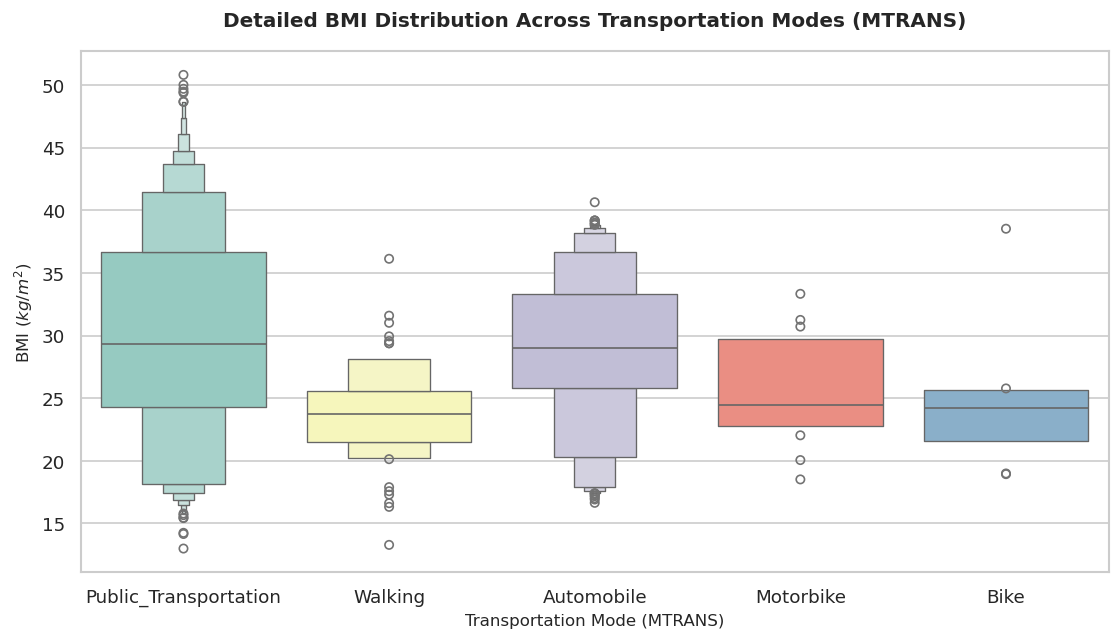

In [146]:
plt.figure(figsize=(9.5, 5.5))

sns.boxenplot(
    data=obesity_plot,
    x="MTRANS",
    y="BMI",
    hue="MTRANS", 
    palette="Set3",
    legend=False,  
    linewidth=0.8,
)

plt.title(
    "Detailed BMI Distribution Across Transportation Modes (MTRANS)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Transportation Mode (MTRANS)", fontsize=10)
plt.ylabel("BMI ($kg/m^2$)", fontsize=10)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

20.Lifestyle Profile: Normal Weight vs. Obesity Type III

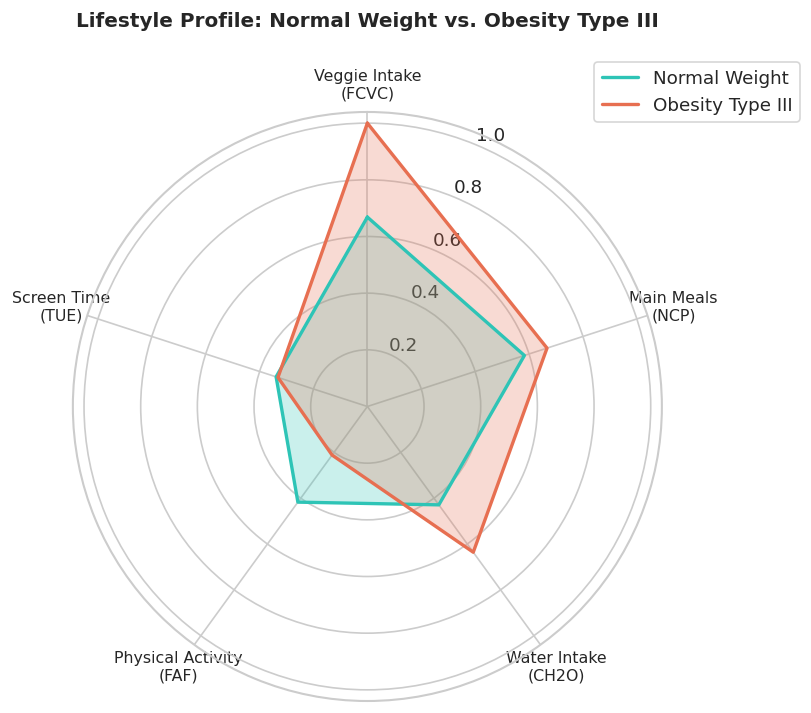

In [147]:
from sklearn.preprocessing import MinMaxScaler  

features = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

df_radar = obesity_plot[
    obesity_plot["NObeyesdad"]
    .astype(str)
    .str.contains("Normal|Type_III|Type III", case=False, na=False)
].copy()

scaler = MinMaxScaler()
df_radar[features] = scaler.fit_transform(df_radar[features])

df_radar["Weight_Group"] = df_radar["NObeyesdad"].apply(
    lambda x: "Obesity Type III" if "Type" in str(x) else "Normal Weight"
)

grouped = df_radar.groupby("Weight_Group")[features].mean()

labels = [
    "Veggie Intake\n(FCVC)",
    "Main Meals\n(NCP)",
    "Water Intake\n(CH2O)",
    "Physical Activity\n(FAF)",
    "Screen Time\n(TUE)",
]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

values_normal = grouped.loc["Normal Weight"].tolist()
values_normal += values_normal[:1]
ax.plot(
    angles,
    values_normal,
    color="#2EC4B6",
    linewidth=2,
    label="Normal Weight",
)
ax.fill(angles, values_normal, color="#2EC4B6", alpha=0.25)

values_obese = grouped.loc["Obesity Type III"].tolist()
values_obese += values_obese[:1]
ax.plot(
    angles,
    values_obese,
    color="#E76F51",
    linewidth=2,
    label="Obesity Type III",
)
ax.fill(angles, values_obese, color="#E76F51", alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels, size=9.5)

plt.title(
    "Lifestyle Profile: Normal Weight vs. Obesity Type III",
    fontsize=12,
    fontweight="bold",
    pad=25,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=True)

plt.tight_layout()
plt.show()

Part  8

Machine Learning Modelling

Introduction

This section develops and compares three supervised machine learning classification models to predict obesity levels (NObeyesdad). The selected models are K-Nearest Neighbors (KNN), Decision Tree, and Naïve Bayes. These algorithms were chosen because they are commonly used classification techniques and were covered in the course syllabus.

Data Preparation(只要run一次罢了）才可以run三个Model

In [148]:
# Define Features and Target
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1667, 17)
Testing Set: (417, 17)


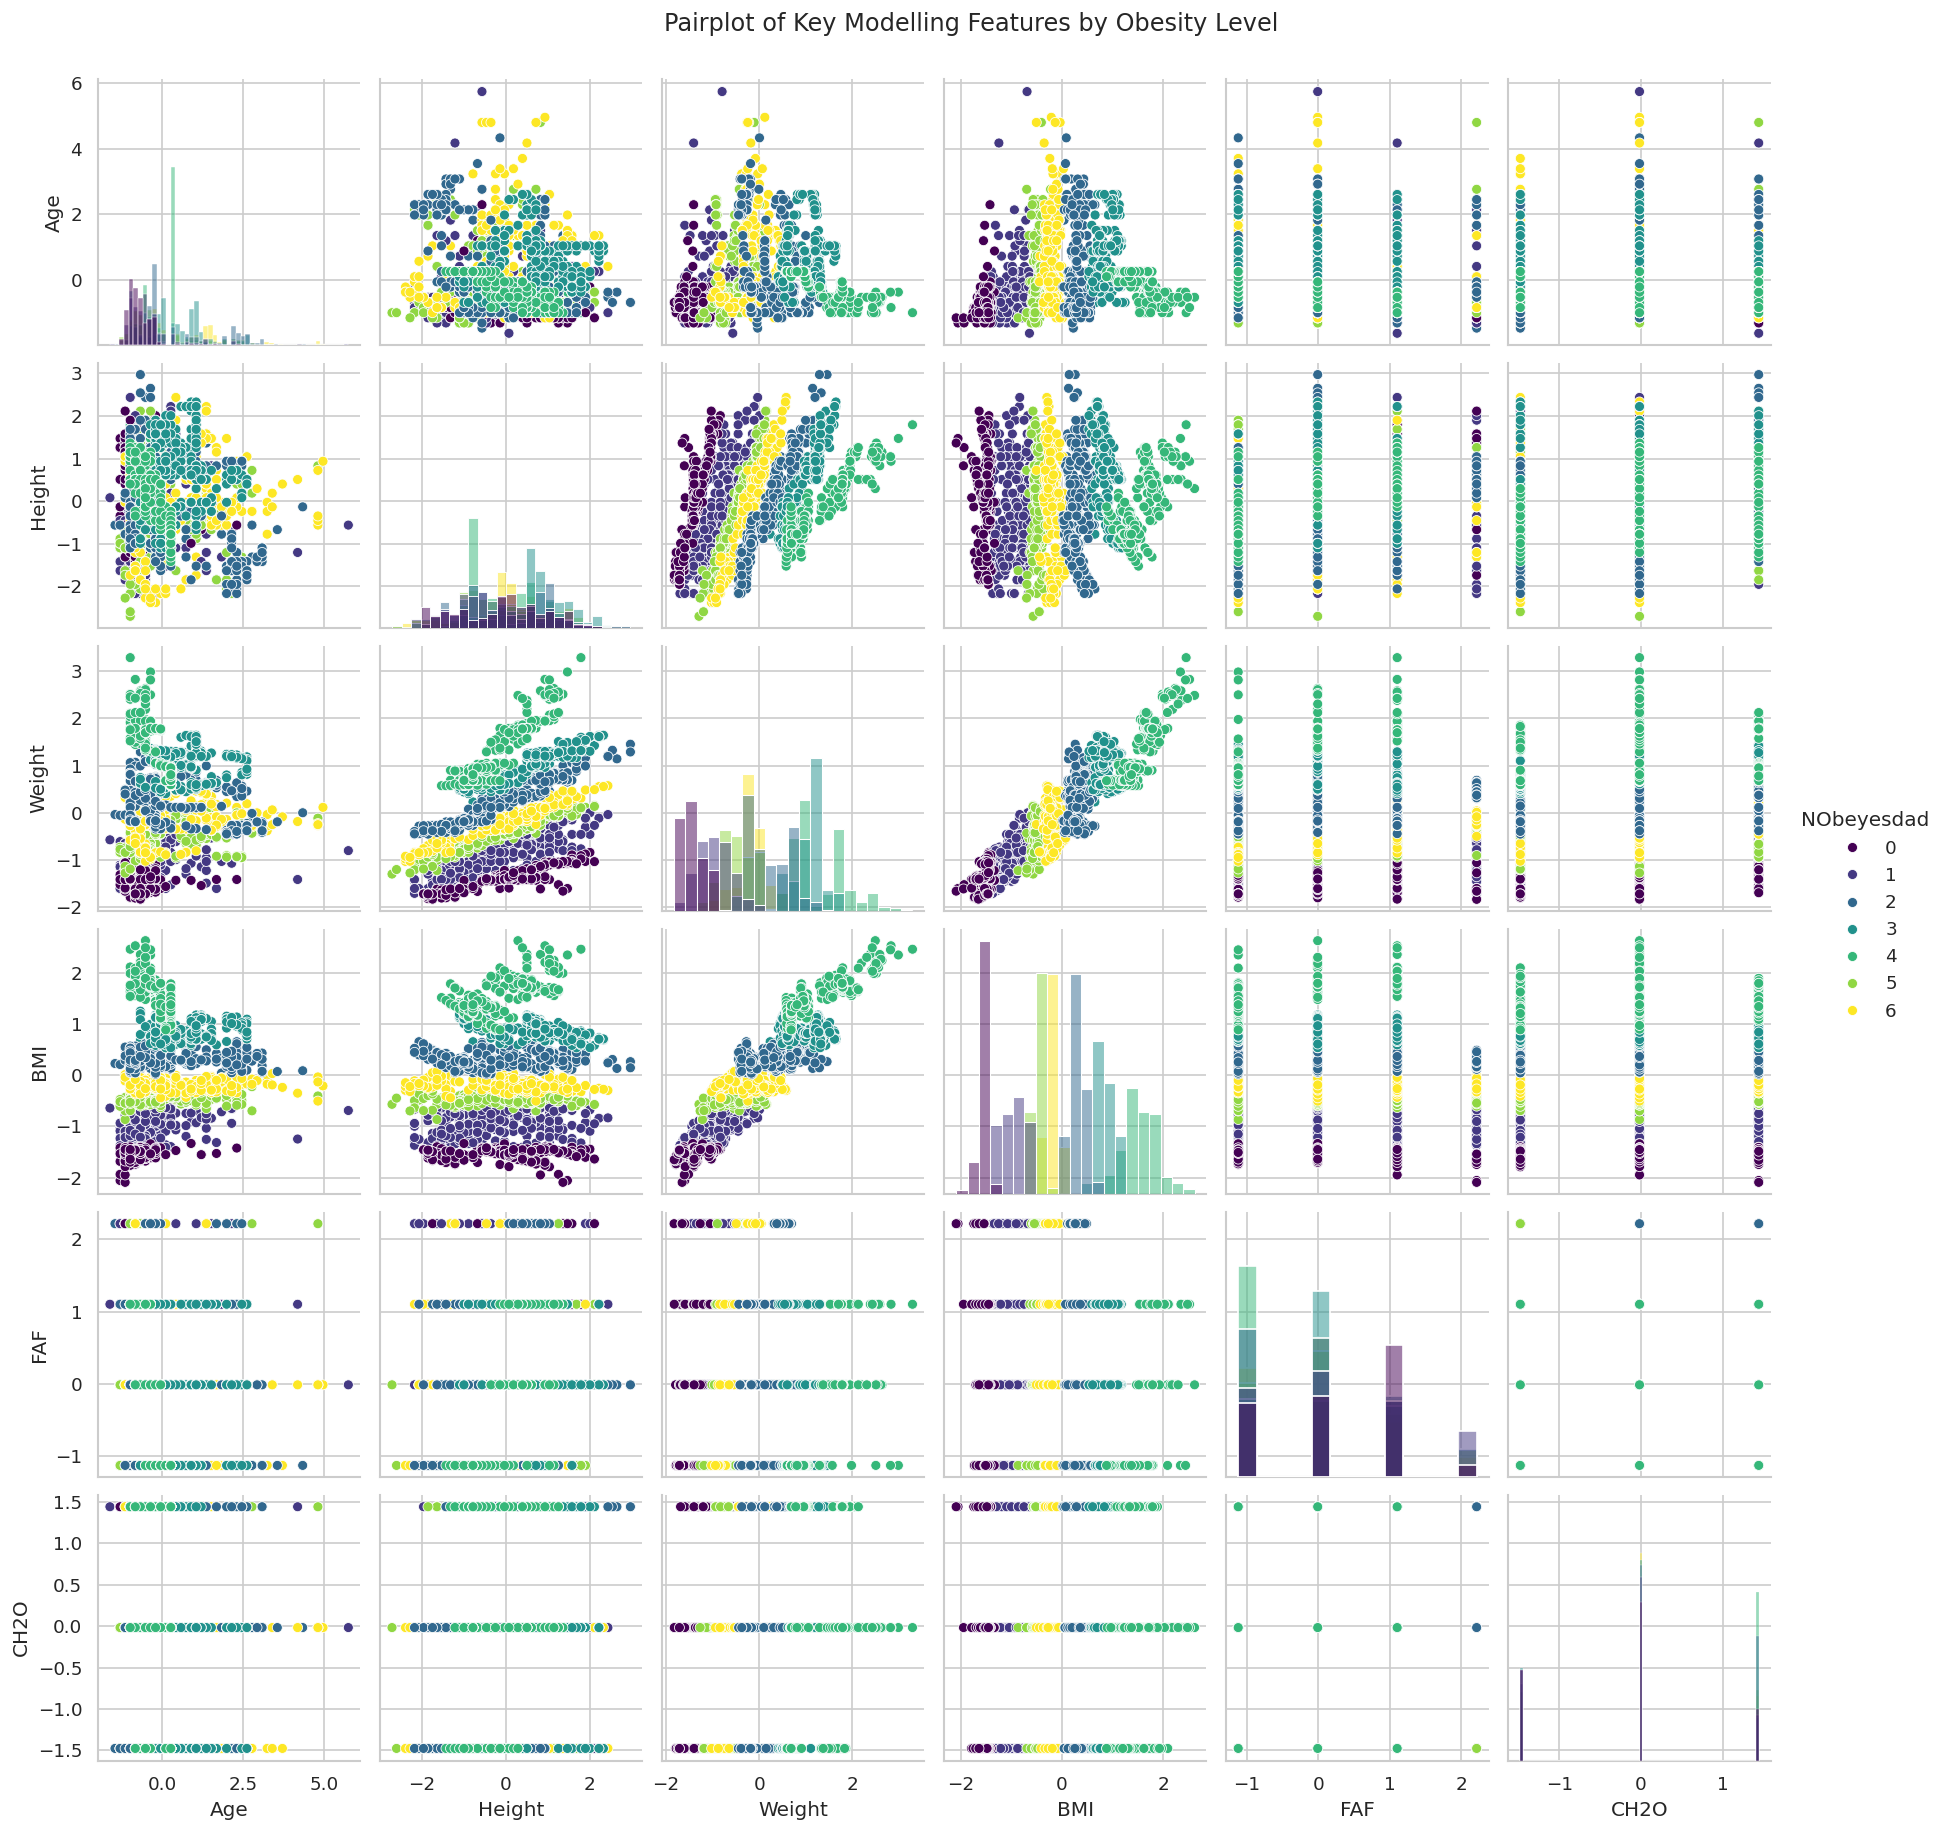

In [149]:
#Pairplot
pairplot_cols = ["Age", "Height", "Weight", "BMI", "FAF", "CH2O", "NObeyesdad"]

sns.pairplot(obesity[pairplot_cols], hue="NObeyesdad", palette="viridis", diag_kind="hist")
plt.suptitle("Pairplot of Key Modelling Features by Obesity Level", y=1.02)
plt.show()

In [150]:
#Ordinal Severity Mapping
severity_map = {
    0: 0,  # Insufficient_Weight
    1: 1,  # Normal_Weight
    2: 4,  # Obesity_Type_I
    3: 5,  # Obesity_Type_II
    4: 6,  # Obesity_Type_III
    5: 2,  # Overweight_Level_I
    6: 3,  # Overweight_Level_II
}

y_test_severity = y_test.map(severity_map)

8.1 KNN

Introduction

K-Nearest Neighbors (KNN) is a classification algorithm that predicts the class of a new observation based on the majority class of its nearest neighbours. It is suitable for obesity classification because similar individuals tend to share similar obesity levels.

Following the approach used in Practical 6a, 5-fold cross-validation (`cross_val_score`) is applied on the training set first to obtain a more reliable estimate of model performance before evaluating on the held-out test set.

In [151]:
knn = KNeighborsClassifier(n_neighbors=5)

# 5-Fold Cross-Validation on the training set
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print("KNN Cross-Validation Scores:", knn_cv_scores)
print("KNN Mean CV Accuracy:", round(knn_cv_scores.mean(), 4))

# Fit on the full training set and evaluate on the held-out test set
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

KNN Cross-Validation Scores: [0.82634731 0.77844311 0.76576577 0.83483483 0.77477477]
KNN Mean CV Accuracy: 0.796


8.1.1 Hyperparameter Tuning for KNN (GridSearchCV)

As demonstrated in Practical 5a, GridSearchCV is used to search for the best value of n_neighbors instead of relying on a single, arbitrarily chosen value (k = 5). The tuned model is then used for the remaining evaluation steps.

In [152]:
from sklearn.model_selection import GridSearchCV

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy"
)

knn_grid.fit(X_train_scaled, y_train)

print("Best n_neighbors:", knn_grid.best_params_["n_neighbors"])
print("Best CV Accuracy:", round(knn_grid.best_score_, 4))

# Replace the baseline KNN with the tuned model for the rest of the evaluation
knn = knn_grid.best_estimator_
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("Tuned KNN Mean CV Accuracy:", round(knn_cv_scores.mean(), 4))

Best n_neighbors: 7
Best CV Accuracy: 0.8668
Tuned KNN Mean CV Accuracy: 0.8668


GridSearchCV identifies the value of k that maximises cross-validation accuracy, which should perform at least as well as the arbitrarily chosen k = 5 used in the baseline model.

8.2 Decision Tree

Introduction

Decision Tree is a supervised learning algorithm that classifies observations by splitting the dataset into decision rules. It is highly interpretable and can capture nonlinear relationships among variables.

As with KNN, 5-fold cross-validation is used first to check how stable the Decision Tree's performance is across different subsets of the training data.

In [153]:
dt = DecisionTreeClassifier(random_state=42)

# 5-Fold Cross-Validation on the training set
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print("Decision Tree Cross-Validation Scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", round(dt_cv_scores.mean(), 4))

# Fit on the full training set and evaluate on the held-out test set
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

Decision Tree Cross-Validation Scores: [0.9760479  0.97904192 0.96096096 0.98498498 0.97297297]
Decision Tree Mean CV Accuracy: 0.9748


8.2.1 Hyperparameter Tuning for Decision Tree (GridSearchCV)

The same grid search approach is applied to the Decision Tree to tune max_depth, min_samples_split and criterion, which helps reduce overfitting compared to an unconstrained tree.



In [154]:
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 3, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.001]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Accuracy:", round(dt_grid.best_score_, 4))

# Replace the baseline Decision Tree with the tuned model for the rest of the evaluation
dt = dt_grid.best_estimator_
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Tuned Decision Tree Mean CV Accuracy:", round(dt_cv_scores.mean(), 4))

Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.9778
Tuned Decision Tree Mean CV Accuracy: 0.9778


Constraining max_depth and min_samples_split typically improves generalisation on the test set compared to an unconstrained Decision Tree, which tends to overfit the training data.

8.3 Support Vector Machine (SVM)

Introduction

Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal boundary (hyperplane) that best separates the classes. It is included here as an additional model, following the SVM demonstration in Practical 5a, to see whether it outperforms KNN, Decision Tree and Naive Bayes on this dataset.

8.3.1 Effect of the C Parameter (as explored in Practical 5a)

Before finalising the model, the effect of the regularisation parameter C is briefly explored. A small C allows a wider margin (more regularisation), while a large C fits the training data more closely and risks overfitting.

In [155]:
from sklearn.svm import SVC

for c_value in [0.1, 1, 10, 100]:
    svc_test = SVC(kernel="rbf", C=c_value).fit(X_train_scaled, y_train)
    train_acc = svc_test.score(X_train_scaled, y_train)
    test_acc = svc_test.score(X_test_scaled, y_test)
    print(f"C={c_value:<6} Train Accuracy: {train_acc:.4f}   Test Accuracy: {test_acc:.4f}")

C=0.1    Train Accuracy: 0.7798   Test Accuracy: 0.7506
C=1      Train Accuracy: 0.9610   Test Accuracy: 0.9209
C=10     Train Accuracy: 0.9994   Test Accuracy: 0.9472
C=100    Train Accuracy: 1.0000   Test Accuracy: 0.9472


8.4.2 Hyperparameter Tuning for SVM (GridSearchCV)

In [156]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "poly"],
    "gamma": ["scale"],
    "degree": [2, 3]
}
svm_grid = GridSearchCV(
    SVC(),
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy"
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Accuracy:", round(svm_grid.best_score_, 4))

svm = svm_grid.best_estimator_
svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("SVM Mean CV Accuracy:", round(svm_cv_scores.mean(), 4))

Best Parameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.964
SVM Mean CV Accuracy: 0.964


Part 9 : Model Evaluation

9.1 Accuracy

In [157]:
knn_accuracy = accuracy_score(y_test, knn_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("KNN Accuracy:", round(knn_accuracy,4))
print("Decision Tree Accuracy:", round(dt_accuracy,4))
print("SVM Accuracy:", round(svm_accuracy,4))

KNN Accuracy: 0.8969
Decision Tree Accuracy: 0.9688
SVM Accuracy: 0.9688


9.2 Calculate RMSE

In [158]:
from sklearn.metrics import mean_squared_error

# The hypothesis of each model turn into severity rank
knn_pred_severity = pd.Series(knn_pred).map(severity_map)
dt_pred_severity  = pd.Series(dt_pred).map(severity_map)
svm_pred_severity = pd.Series(svm_pred).map(severity_map)

knn_rmse = np.sqrt(mean_squared_error(y_test_severity, knn_pred_severity))
dt_rmse  = np.sqrt(mean_squared_error(y_test_severity, dt_pred_severity))
svm_rmse = np.sqrt(mean_squared_error(y_test_severity, svm_pred_severity))

print("KNN RMSE:", round(knn_rmse, 4))
print("Decision Tree RMSE:", round(dt_rmse, 4))
print("SVM RMSE:", round(svm_rmse, 4))

KNN RMSE: 0.5387
Decision Tree RMSE: 0.1766
SVM RMSE: 0.1766


9.3 Classification Report

In [159]:
print("========== KNN ==========")
print(classification_report(y_test, knn_pred))

print("========== Decision Tree ==========")
print(classification_report(y_test, dt_pred))

print("========== SVM ==========")
print(classification_report(y_test, svm_pred))

========== KNN ==========
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        53
           1       0.88      0.54      0.67        56
           2       0.91      0.96      0.93        70
           3       0.92      1.00      0.96        60
           4       1.00      1.00      1.00        65
           5       0.86      0.89      0.88        55
           6       0.84      0.90      0.87        58

    accuracy                           0.90       417
   macro avg       0.89      0.89      0.89       417
weighted avg       0.90      0.90      0.89       417

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.95      0.93      0.94        56
           2       1.00      0.94      0.97        70
           3       0.94      1.00      0.97        60
           4       1.00      1.00      1.00        65
           5    

Interpretation

The classification report evaluates Precision, Recall, and F1-score for each obesity class. These metrics provide a more comprehensive evaluation than accuracy alone, particularly when class distributions are not perfectly balanced.

9.4 Confusion Matrix

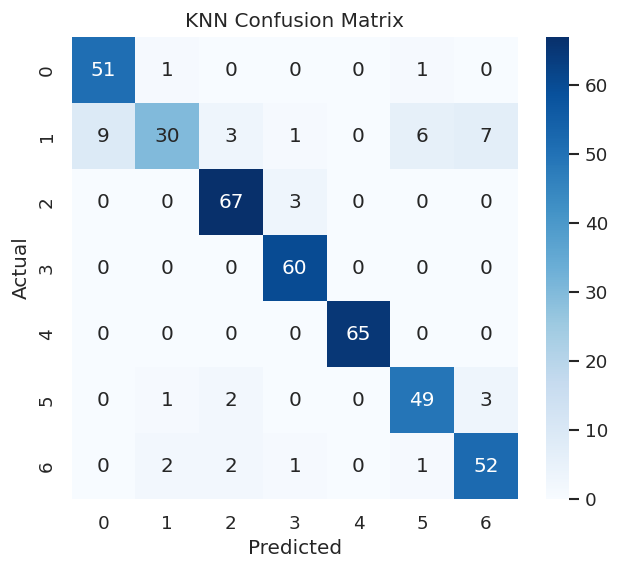

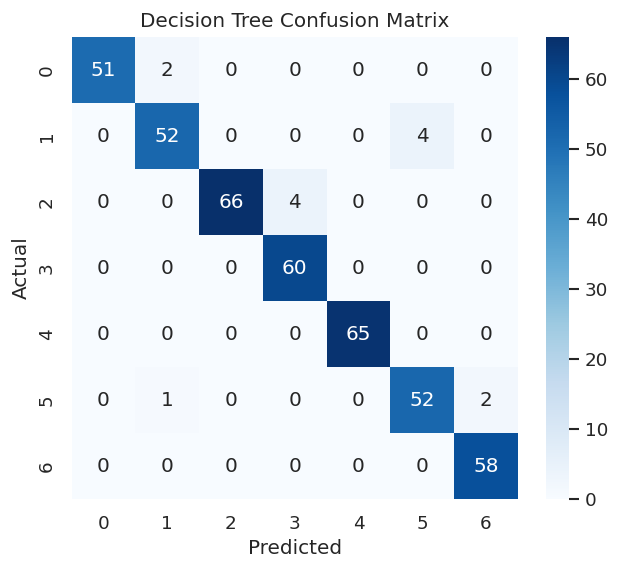

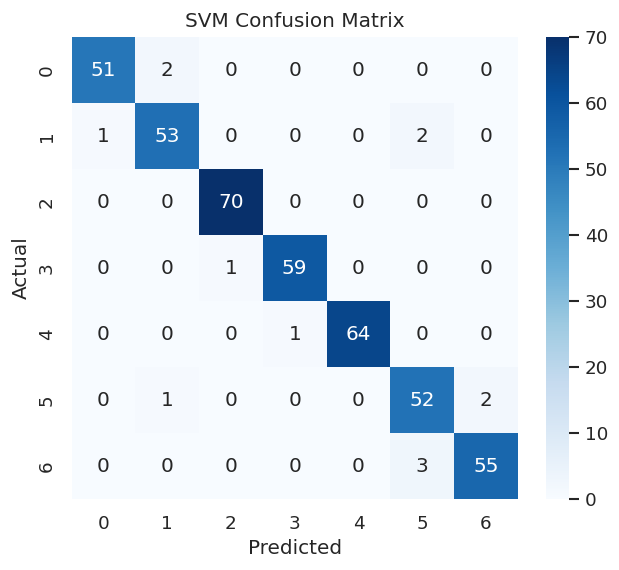

In [160]:
models = {
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "SVM": svm_pred
}

for name, prediction in models.items():

    cm = confusion_matrix(y_test, prediction)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues")

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Part 10 Model Comparison 

In [161]:
comparison = pd.DataFrame({

    "Model":[
        "KNN",
        "Decision Tree",
        "SVM"
    ],

    "CV Accuracy":[
        knn_cv_scores.mean(),
        dt_cv_scores.mean(),
        svm_cv_scores.mean()
    ],

    "Test Accuracy":[
        knn_accuracy,
        dt_accuracy,
        svm_accuracy
    ]

})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

comparison

,Model,CV Accuracy,Test Accuracy
1,Decision Tree,0.977798,0.968825
2,SVM,0.964009,0.968825
0,KNN,0.866812,0.896882


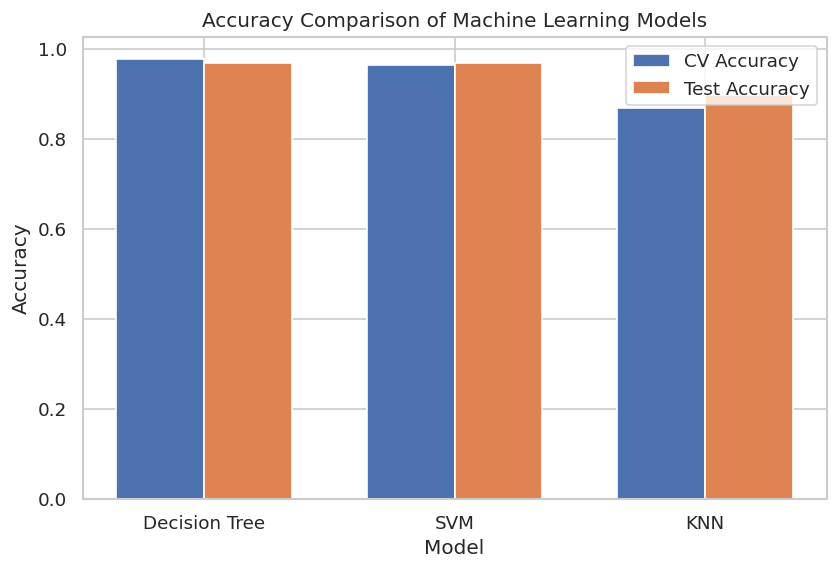

In [162]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, comparison["CV Accuracy"], width, label="CV Accuracy")
plt.bar(x + width/2, comparison["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, comparison["Model"])
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Part 11 Feature Importance (Decision Tree)

In [163]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":dt.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
16,BMI,0.793066
0,Gender,0.168085
3,Weight,0.016843
15,MTRANS,0.006295
1,Age,0.004331
7,NCP,0.003721
11,SCC,0.002658
12,FAF,0.001640
2,Height,0.001418
5,FAVC,0.001098


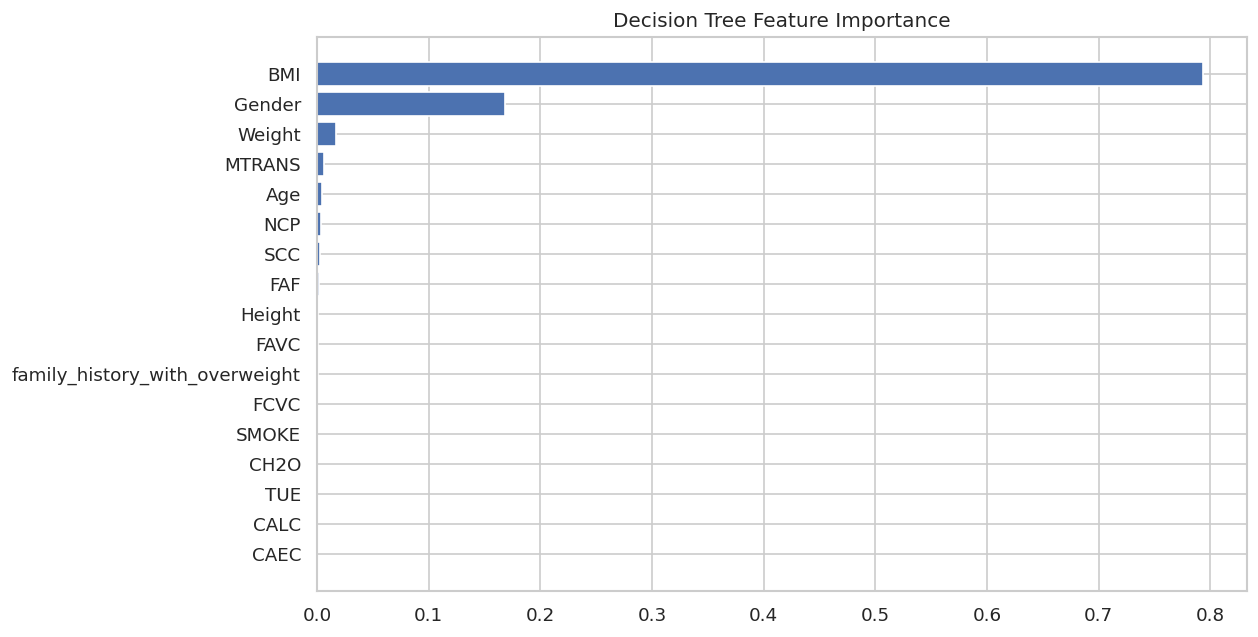

In [164]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [165]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Save the best models
joblib.dump(dt_grid.best_estimator_, "decision_tree.pkl")
joblib.dump(knn_grid.best_estimator_, "knn.pkl")
joblib.dump(svm_grid.best_estimator_, "svm.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

joblib.dump(target_encoder, "target_encoder.pkl")

print("target_encoder.pkl saved successfully!")

print("All models saved successfully!")

target_encoder.pkl saved successfully!
All models saved successfully!


In [167]:
# Load the saved model and preprocessing objects
loaded_model = joblib.load("decision_tree.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_target_encoder = joblib.load("target_encoder.pkl")

# Simulate a new, unseen participant's data
# (columns must match X: Gender, Age, Height, Weight, family_history_with_overweight,
#  FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS, BMI)
new_participant = pd.DataFrame([{
    "Gender": 1,                # Male
    "Age": 28.0,
    "Height": 1.75,
    "Weight": 95.0,
    "family_history_with_overweight": 1,
    "FAVC": 1,
    "FCVC": 2.0,
    "NCP": 3.0,
    "CAEC": 2.0,
    "SMOKE": 0,
    "CH2O": 2.0,
    "SCC": 0,
    "FAF": 0.0,
    "TUE": 1.0,
    "CALC": 1.0,
    "MTRANS": 0,
    "BMI": 95.0 / (1.75 ** 2)
}])

prediction = loaded_model.predict(new_participant)
predicted_class = loaded_target_encoder.inverse_transform(prediction)

print("Predicted Obesity Level:", predicted_class[0])

Predicted Obesity Level: Obesity_Type_III


Interpretation

Features with higher importance values contribute more significantly to the classification of obesity levels. These variables should receive greater attention when designing obesity prevention strategies.

Part 12 Business Recommendation

Based on the machine learning results, BMI, Weight, and lifestyle-related factors are the most influential predictors of obesity. Therefore, healthcare organizations should promote regular physical activity, encourage balanced diets, and implement early obesity screening programmes. Individuals identified as high-risk can receive targeted interventions to reduce obesity prevalence.

Part 13 Conclusion

This study successfully applied three supervised machine learning algorithms to predict obesity levels. Among the evaluated models, the model with the highest accuracy demonstrated the best predictive performance. The findings also highlighted the importance of body measurements and lifestyle behaviours in obesity prediction. These insights can support healthcare professionals in developing effective obesity prevention and intervention strategies.